# Untied attention model for synthetic datas

In [1]:
from pdb import run
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

# run_id = "20251212_2158" # rho = 1 
# run_id = "20251213_1005" # rho = 0.75
# run_id = "20251213_1804" # rho = 1.5
run_id = "20251215_1148" # rho = 0.5

In [2]:
# --- 1. Global Academic Style Configuration ---

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [3]:
run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

⚙️ Config loaded (15 rows) from ../results/run_20251215_1148/config.csv


,alpha,D,L,rho,rho_star,beta,lam,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,base_dir
0,0.010000,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
1,0.080714,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
2,0.151429,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
3,0.222143,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
4,0.292857,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
5,0.858571,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
6,1.000000,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
7,0.787857,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
8,0.929286,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
9,0.717143,100,2,0.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (105 rows) from ../results/run_20251215_1148/summary.csv


,alpha,alpha_idx,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,label_err_mean_noise,label_err_std_noise,train_data_mean,train_reg_mean,train_total_mean
0,0.01,0,0.1000,0.5,0.009710,4.685584e-11,0.264739,0.004878,0.321190,0.004594,0.003181,4.823779e-09,0.003181
1,0.01,0,0.0100,0.5,0.009678,3.816664e-05,0.269427,0.005657,0.328289,0.006167,0.000211,8.829791e-04,0.001094
2,0.01,0,0.0050,0.5,0.010099,4.874772e-05,0.279211,0.003787,0.334287,0.004601,0.000076,5.356334e-04,0.000611
3,0.01,0,0.0010,0.5,0.010498,5.342440e-05,0.287070,0.005914,0.343624,0.004577,0.000007,1.338947e-04,0.000141
4,0.01,0,0.0005,0.5,0.010018,7.458803e-05,0.283691,0.005814,0.341800,0.007302,0.000002,6.943268e-05,0.000072


✅ Summary loaded (105 rows)
✅ Saved plot: ../results/run_20251215_1148/plots/MSE_vs_alpha_20251215_1148.png


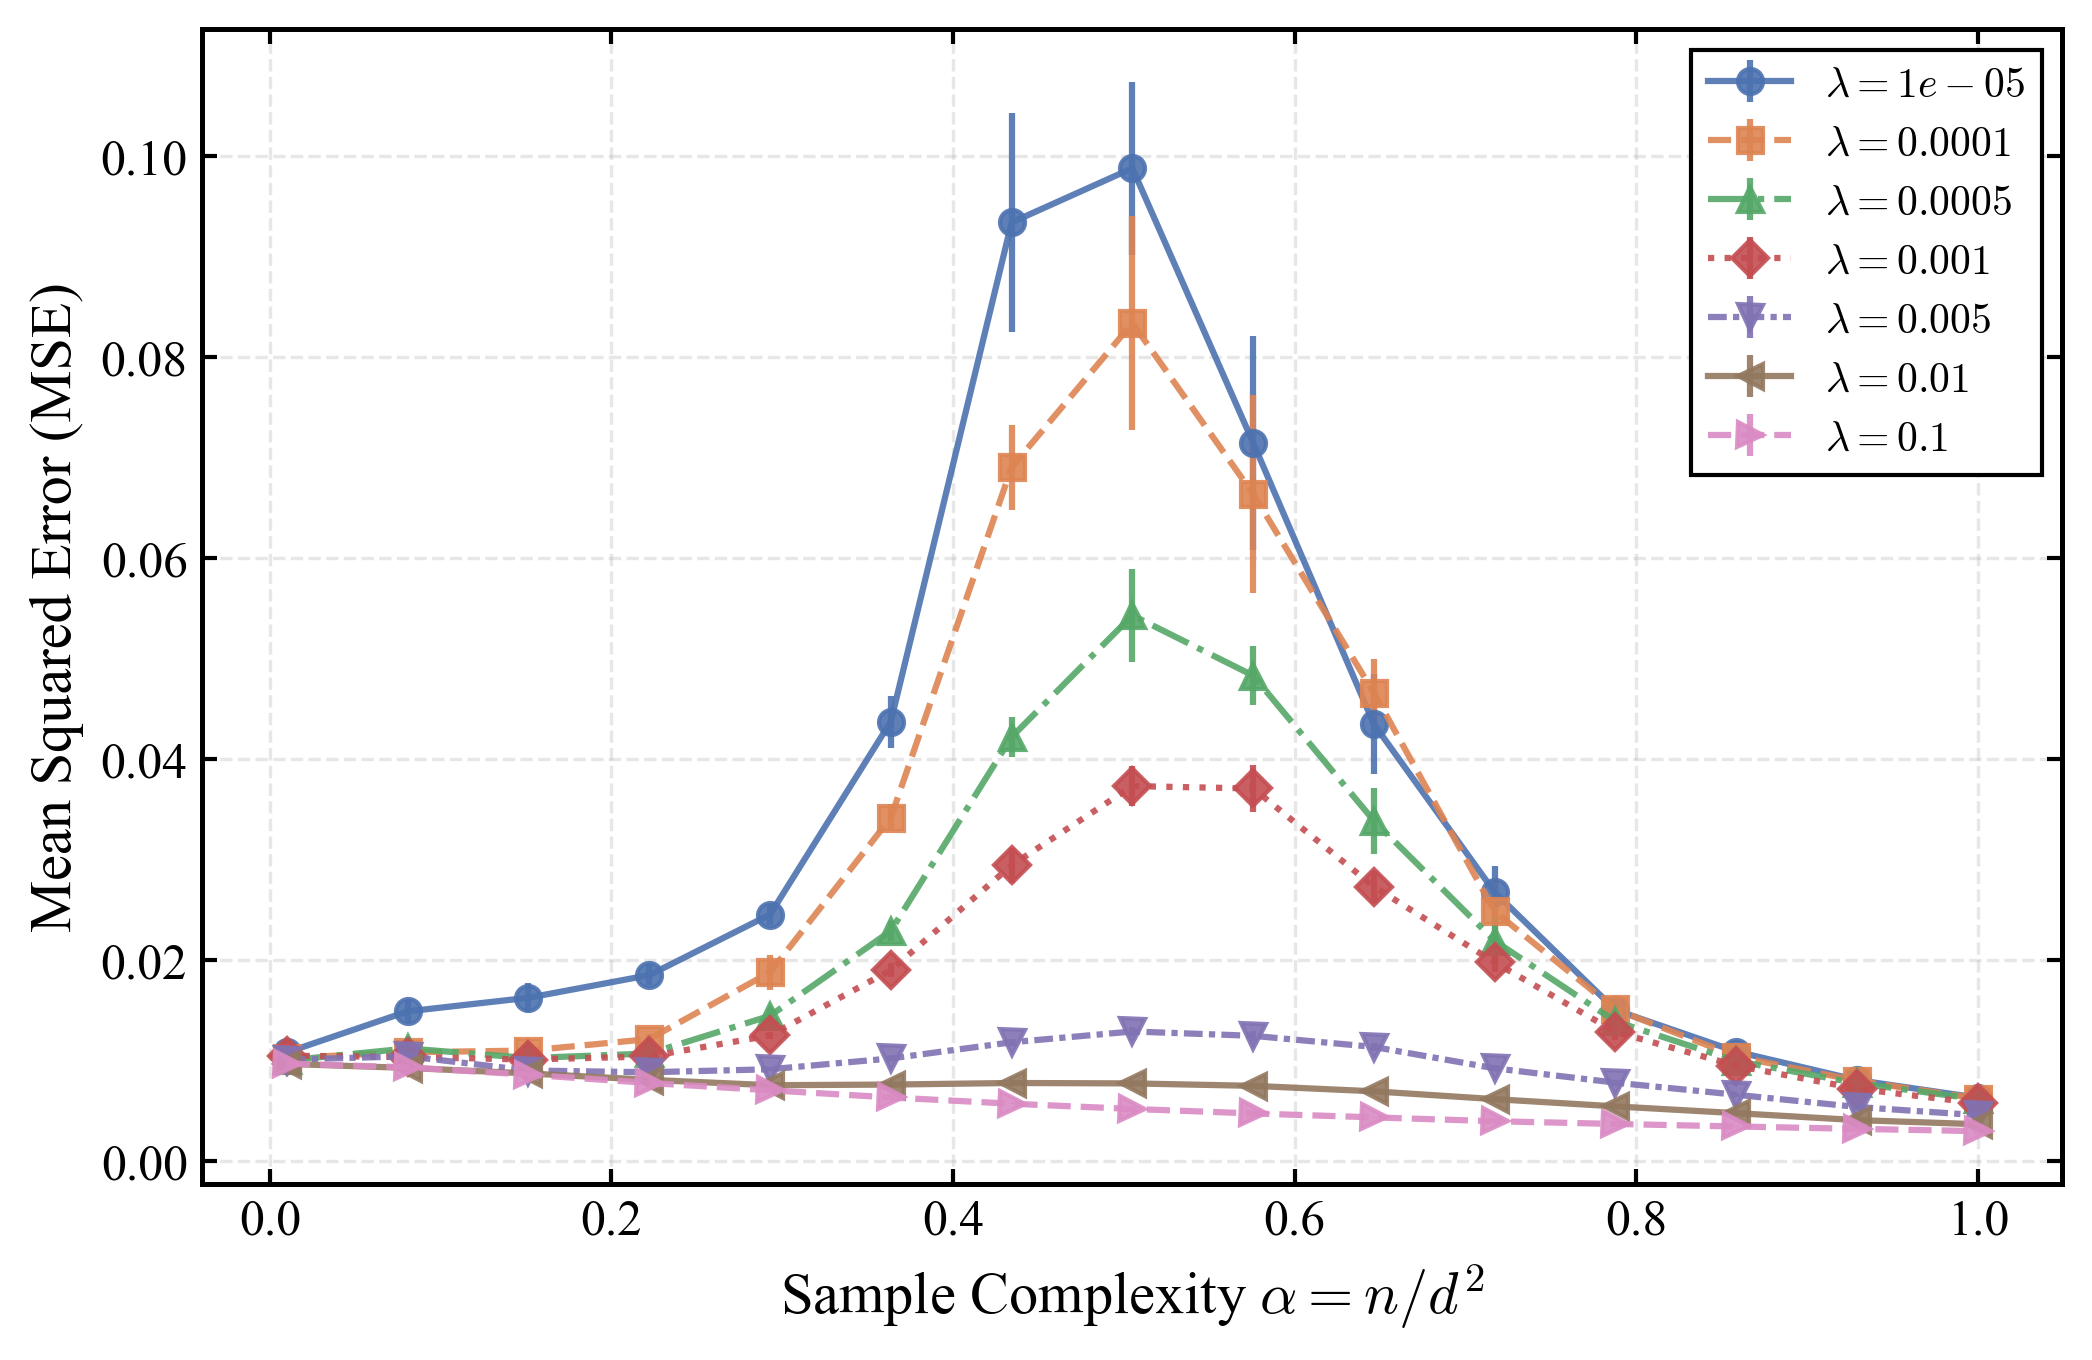

✅ Saved plot: ../results/run_20251215_1148/plots/LabelError_vs_alpha_20251215_1148.png


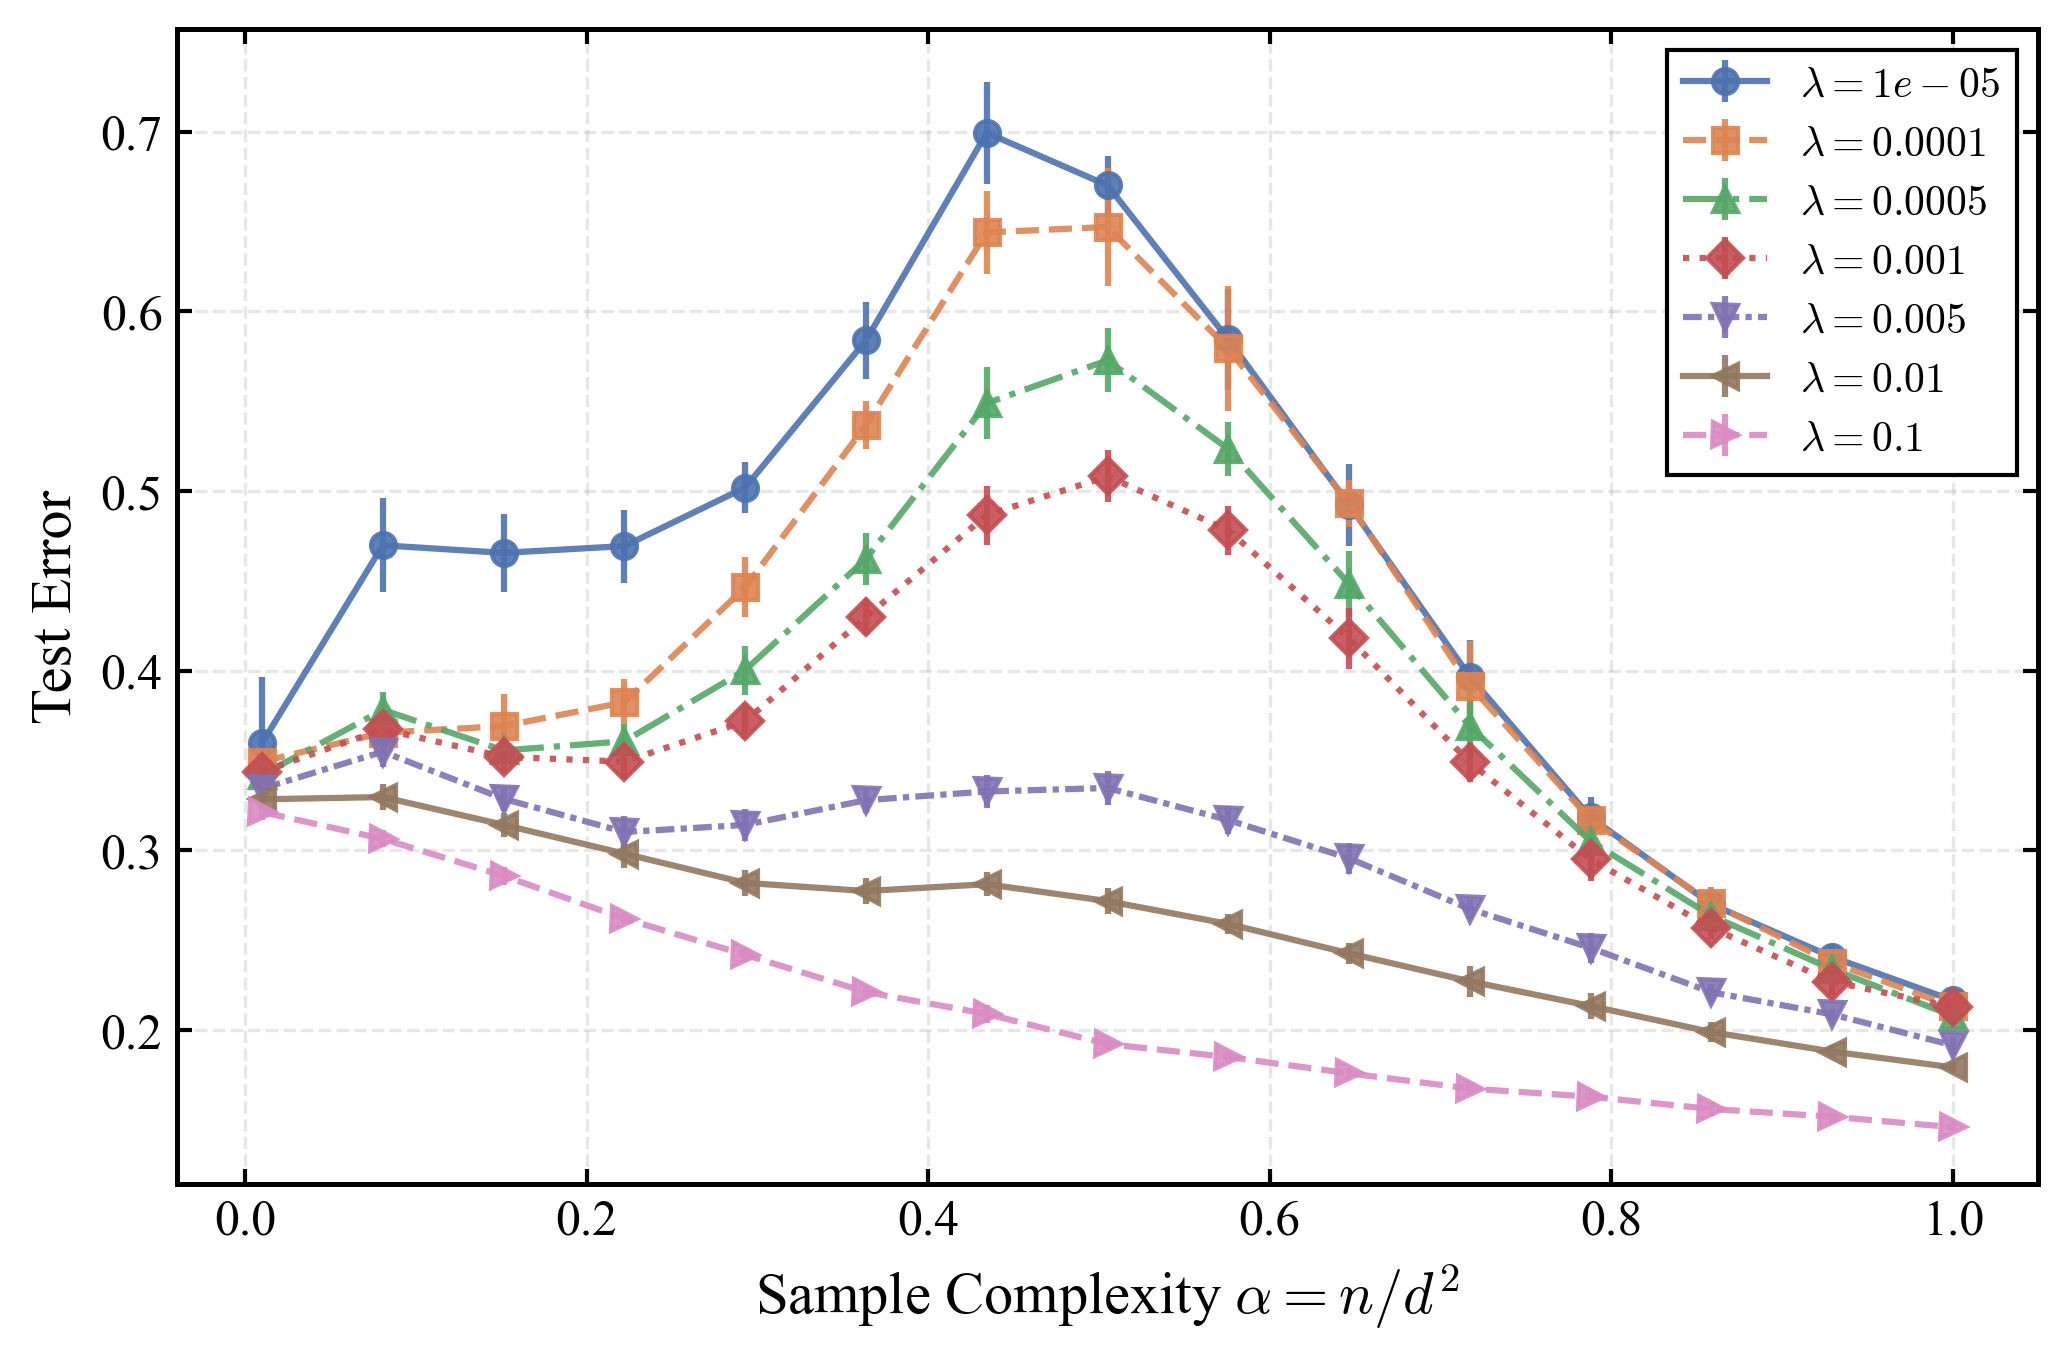

✅ Saved plot: ../results/run_20251215_1148/plots/TrainData_vs_alpha_20251215_1148.png


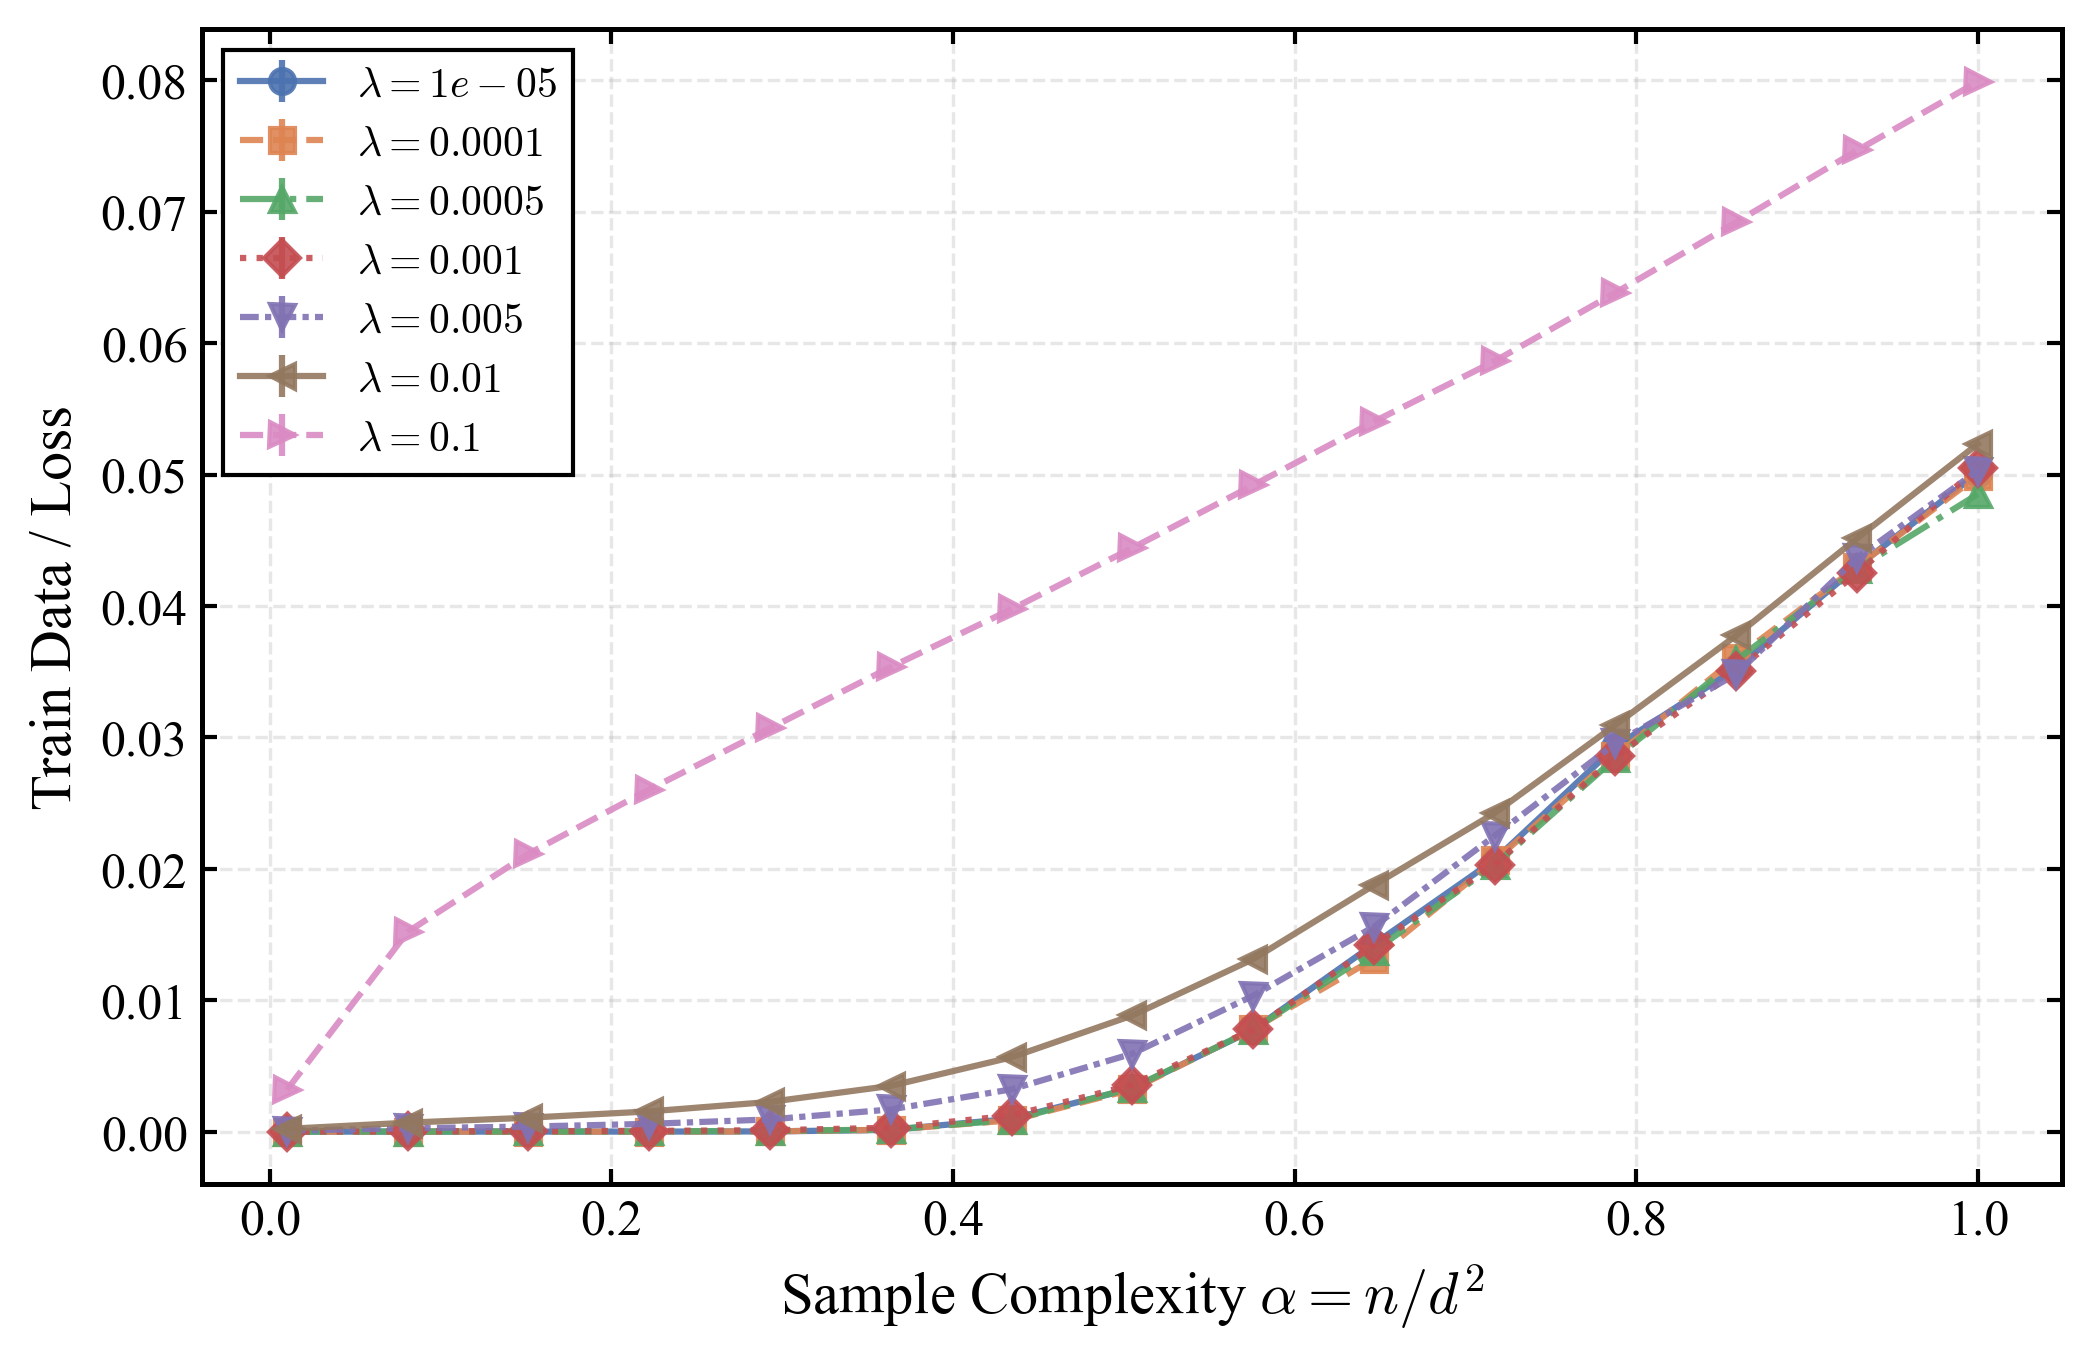

In [4]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- 2. Chargement des données ---
# Assure-toi que base_path et run_id sont définis
# df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows)")

# --- 3. Définition des Styles ---
unique_lams = sorted(df["lam"].unique())
colors = sns.color_palette("deep", n_colors=len(unique_lams))
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

# Gestion des ticks (Optionnel : pour réduire le nombre si trop dense)
# On prend min, max et le milieu par exemple, ou linspace
custom_xticks = np.linspace(df["alpha"].min(), df["alpha"].max(), 5) 

# --- 4. Fonction de Plot Générique ---
def plot_academic_metric(df, y_col, y_err_col, ylabel, file_prefix, run_id, reduce_ticks=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Boucle sur les Lambdas
    for i, lam in enumerate(unique_lams):
        subset = df[df["lam"] == lam].sort_values("alpha")
        
        # Style cyclique
        fmt_color = colors[i % len(colors)]
        fmt_marker = markers[i % len(markers)]
        fmt_ls = linestyles[i % len(linestyles)]
        
        ax.errorbar(
            subset["alpha"], 
            subset[y_col], 
            yerr=subset.get(y_err_col, 0),
            label=fr"$\lambda={lam}$",
            color=fmt_color,
            marker=fmt_marker,
            linestyle=fmt_ls,
            capsize=0,       # Jolis chapeaux pour les erreurs
            elinewidth=1.5,
            alpha=0.9
        )

    # --- Labels ---
    ax.set_xlabel(r"Sample Complexity $\alpha = n / d^2$")
    ax.set_ylabel(ylabel)
    
    # --- Option: Réduction des Ticks ---
    if reduce_ticks:
        ax.set_xticks(custom_xticks)
        ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    # --- STYLE BOÎTE (Box Style) ---
    ax.set_axisbelow(True) 
    # Ticks intérieurs sur les 4 côtés
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    # Bordures noires solides
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    
    # Légende
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')
    
    # Sauvegarde
    filename = f"{file_prefix}_{run_id}.png"
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full)
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 5. Génération des 3 Graphiques ---

# 1. MSE
plot_academic_metric(
    df, 
    y_col="MSE_mean", 
    y_err_col="MSE_std", 
    ylabel="Mean Squared Error (MSE)", 
    file_prefix="MSE_vs_alpha",
    run_id=run_id,
    reduce_ticks=False # Mets True si tu veux activer alpha_ticks
)

# 2. Label Error
plot_academic_metric(
    df, 
    y_col="label_err_mean_noise", 
    y_err_col="label_err_std_noise", 
    ylabel="Test Error", 
    file_prefix="LabelError_vs_alpha",
    run_id=run_id
)

# 3. Train Data
plot_academic_metric(
    df, 
    y_col="train_data_mean", 
    y_err_col="train_data_std", 
    ylabel="Train Data / Loss", 
    file_prefix="TrainData_vs_alpha",
    run_id=run_id
)

## 3. Singular values distributions per $\alpha$ ($\lambda$ fixed)

Normalization constants: D=100, R=50.0
Found 15 W_Q files and 15 W_K files.

Processing pair: W_Q_runs_0.pkl | W_K_runs_0.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_0.png


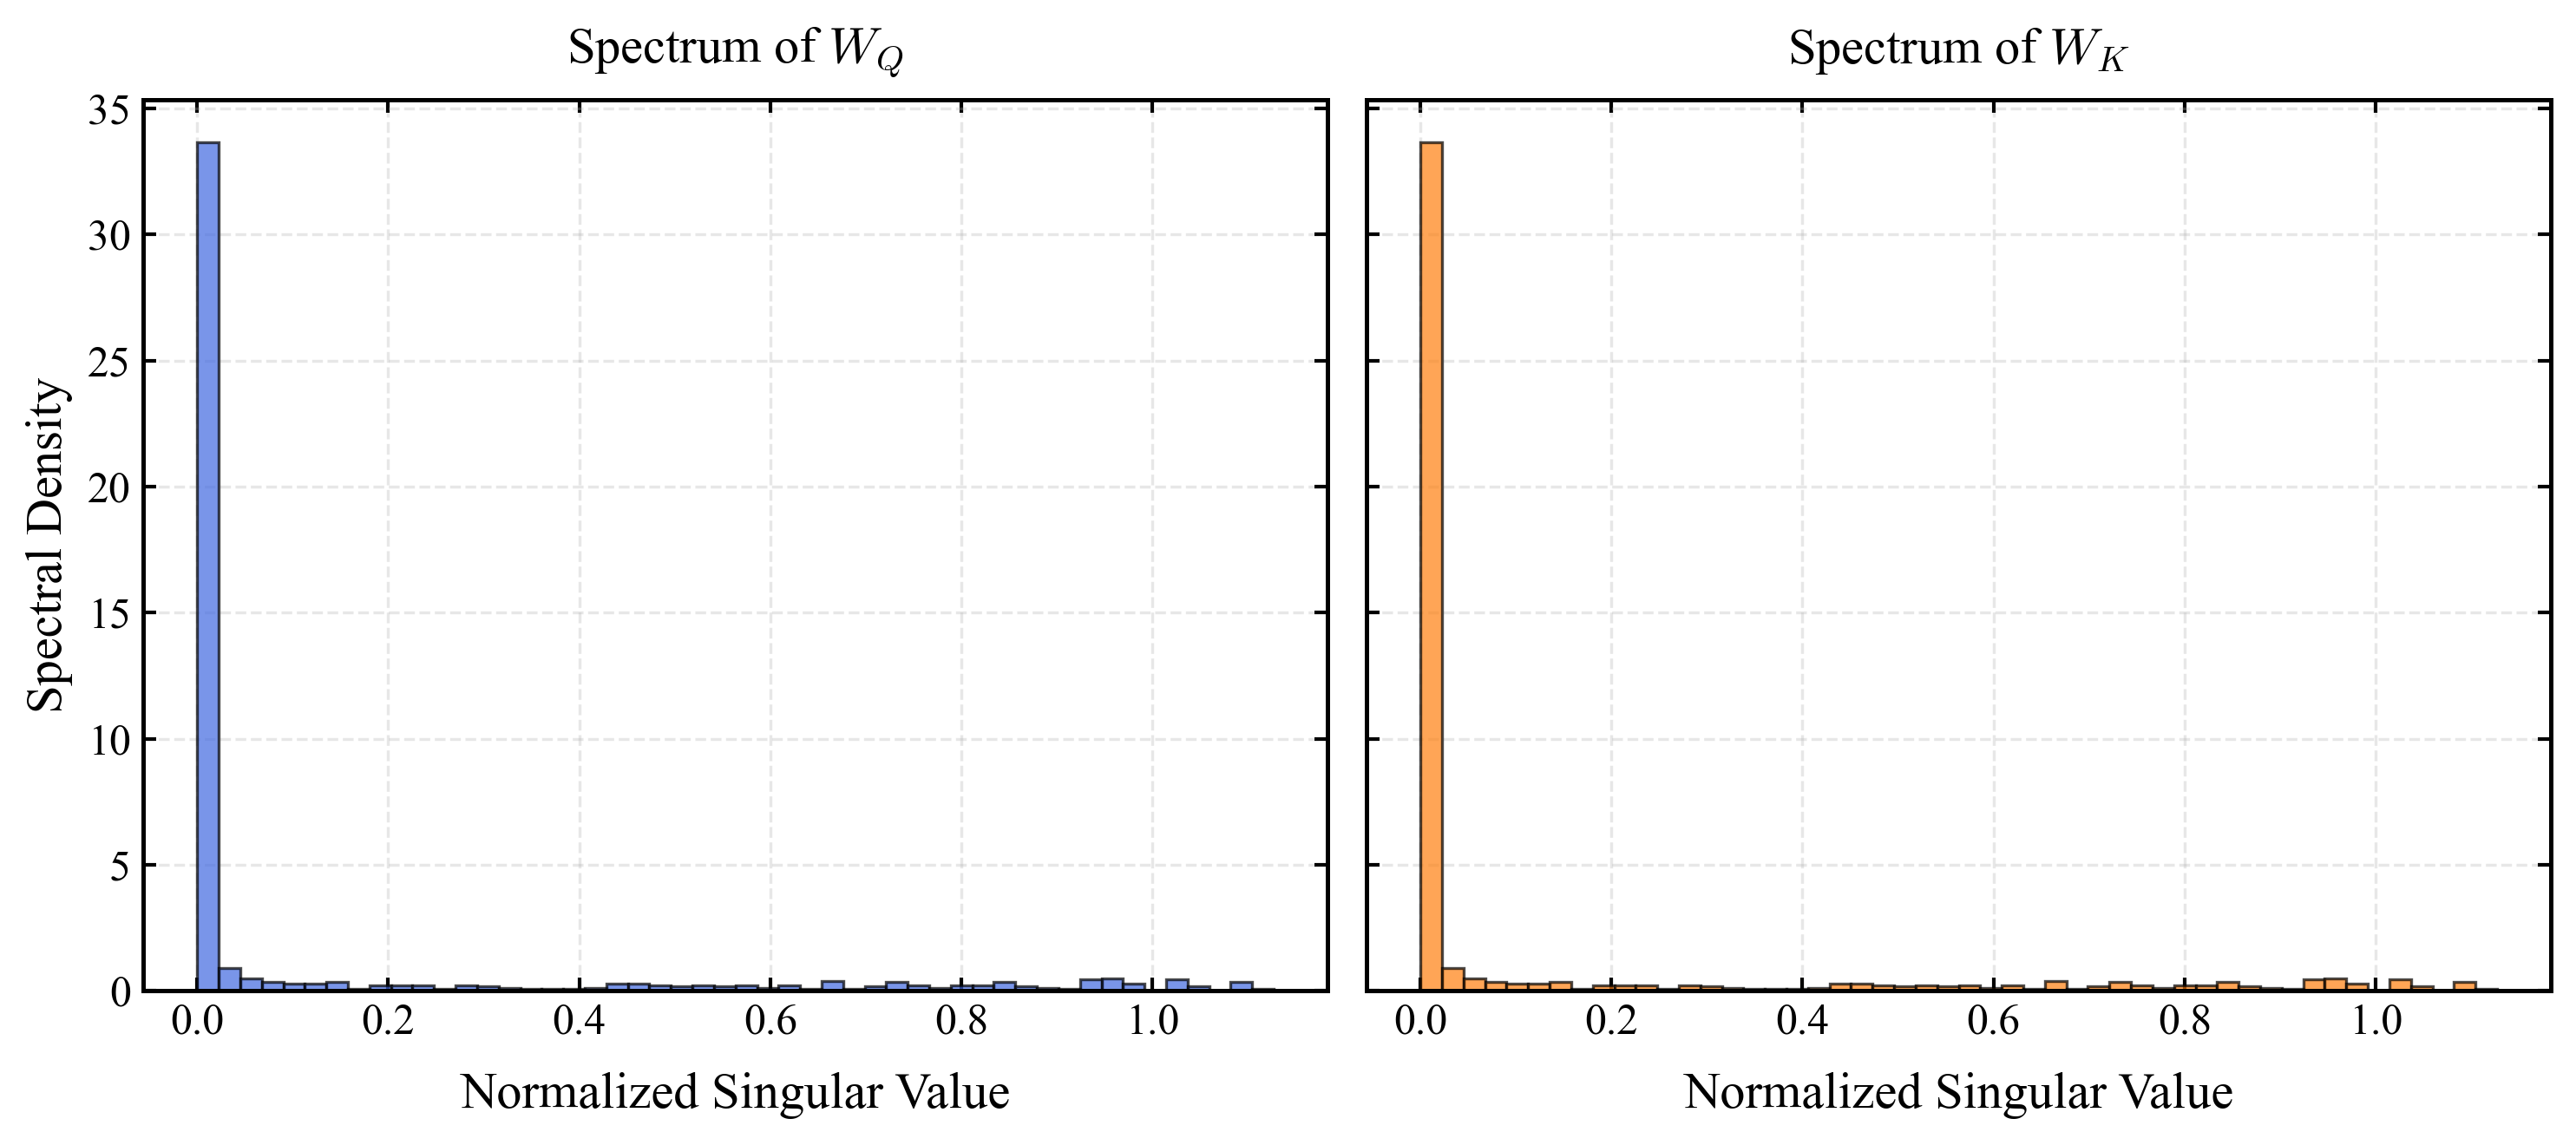


Processing pair: W_Q_runs_1.pkl | W_K_runs_1.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_1.png


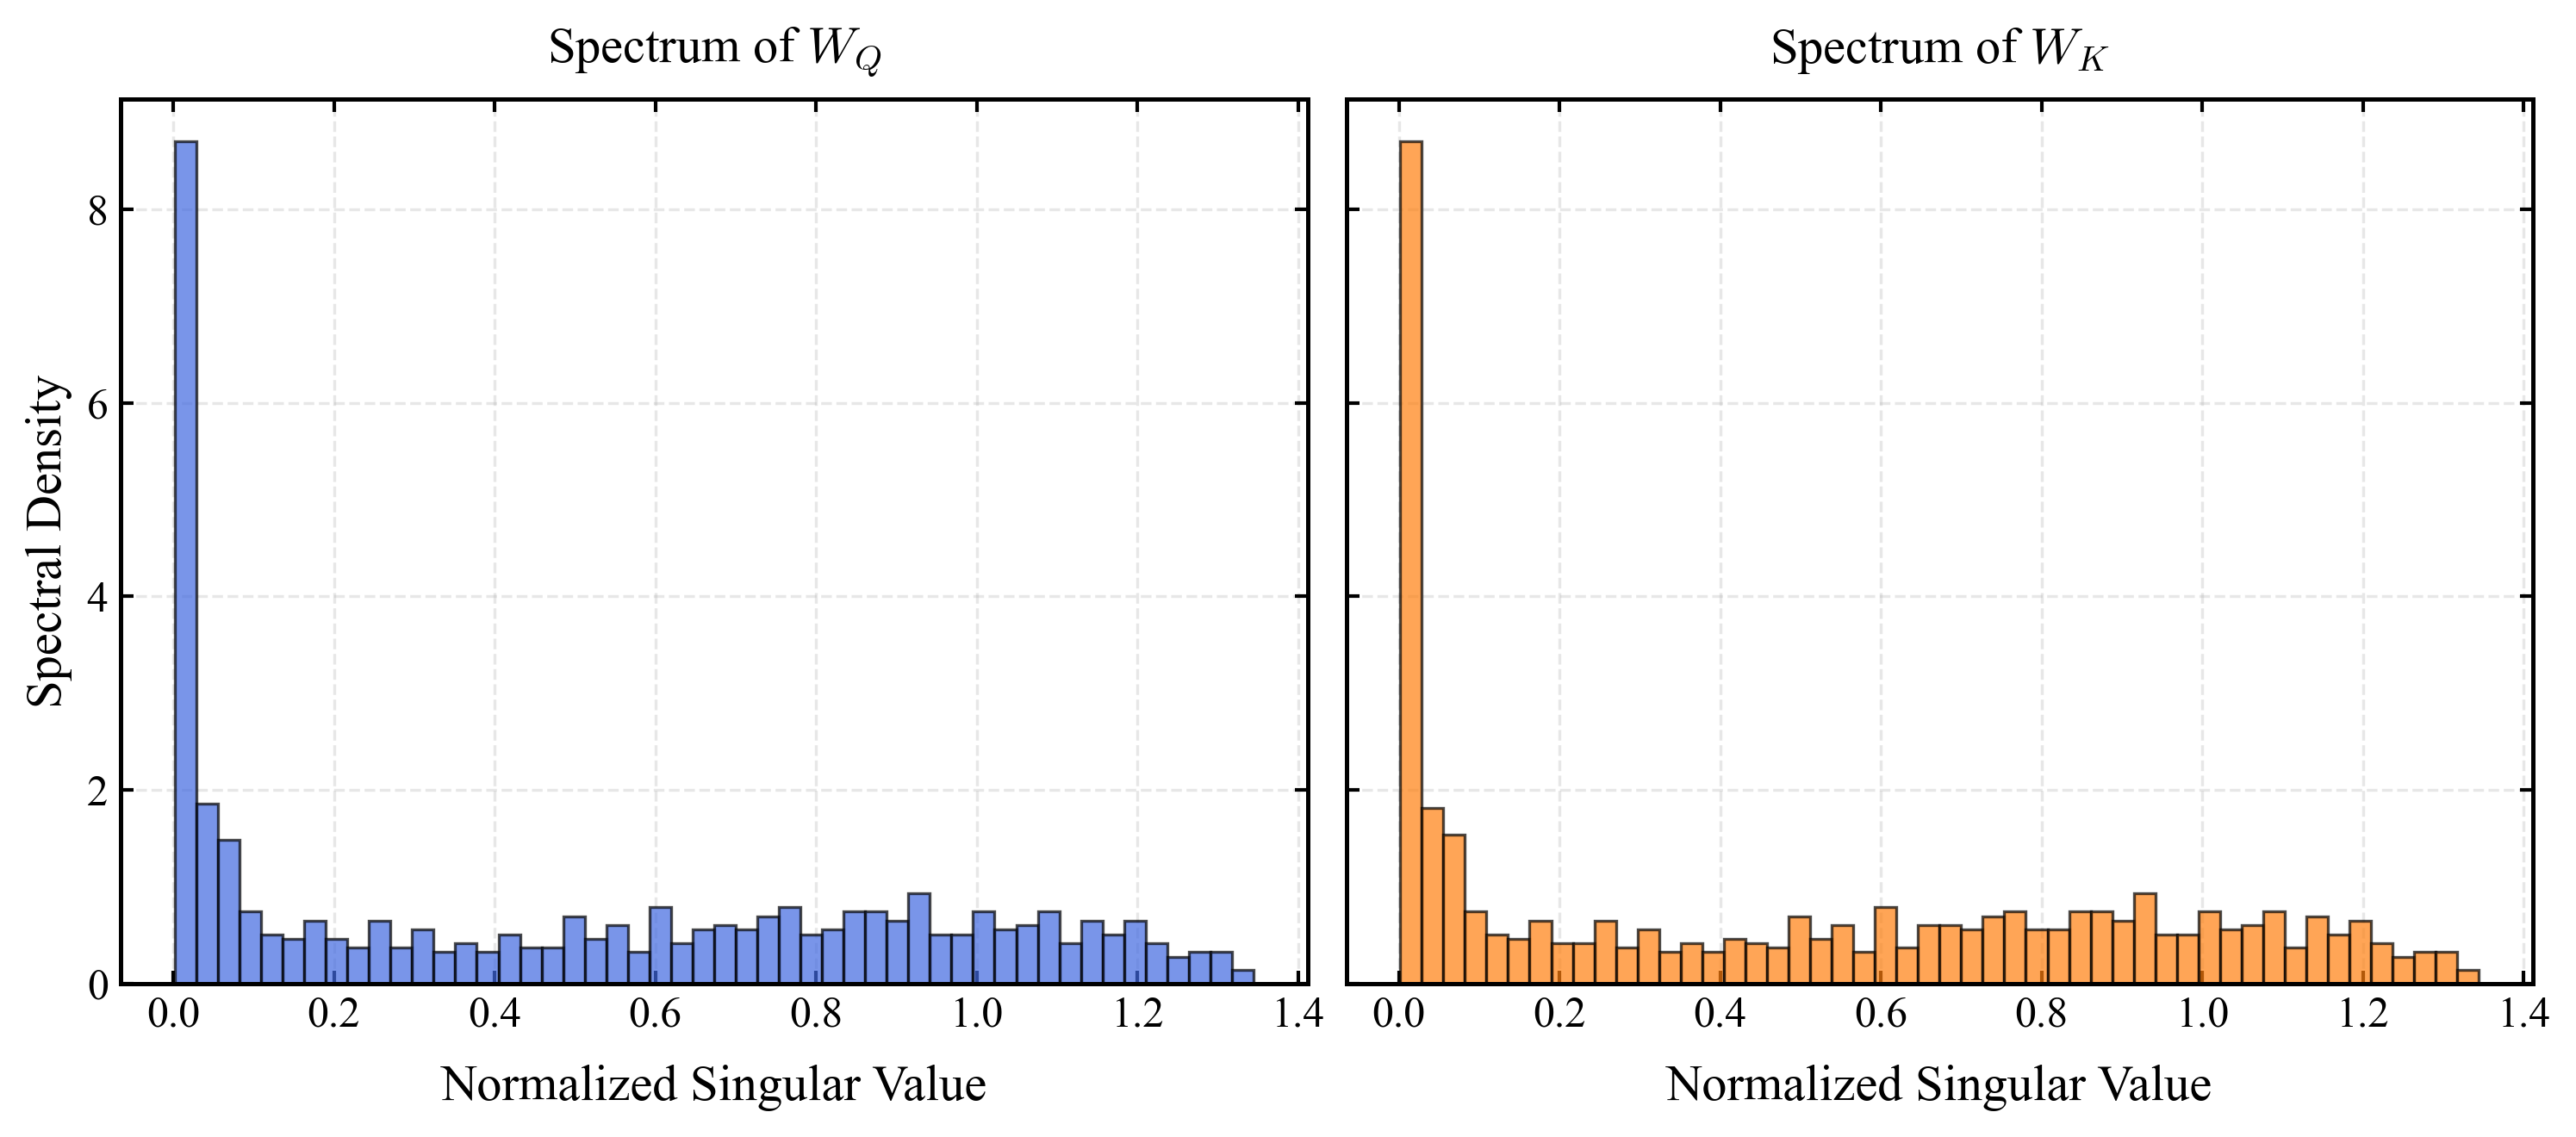


Processing pair: W_Q_runs_10.pkl | W_K_runs_10.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_10.png


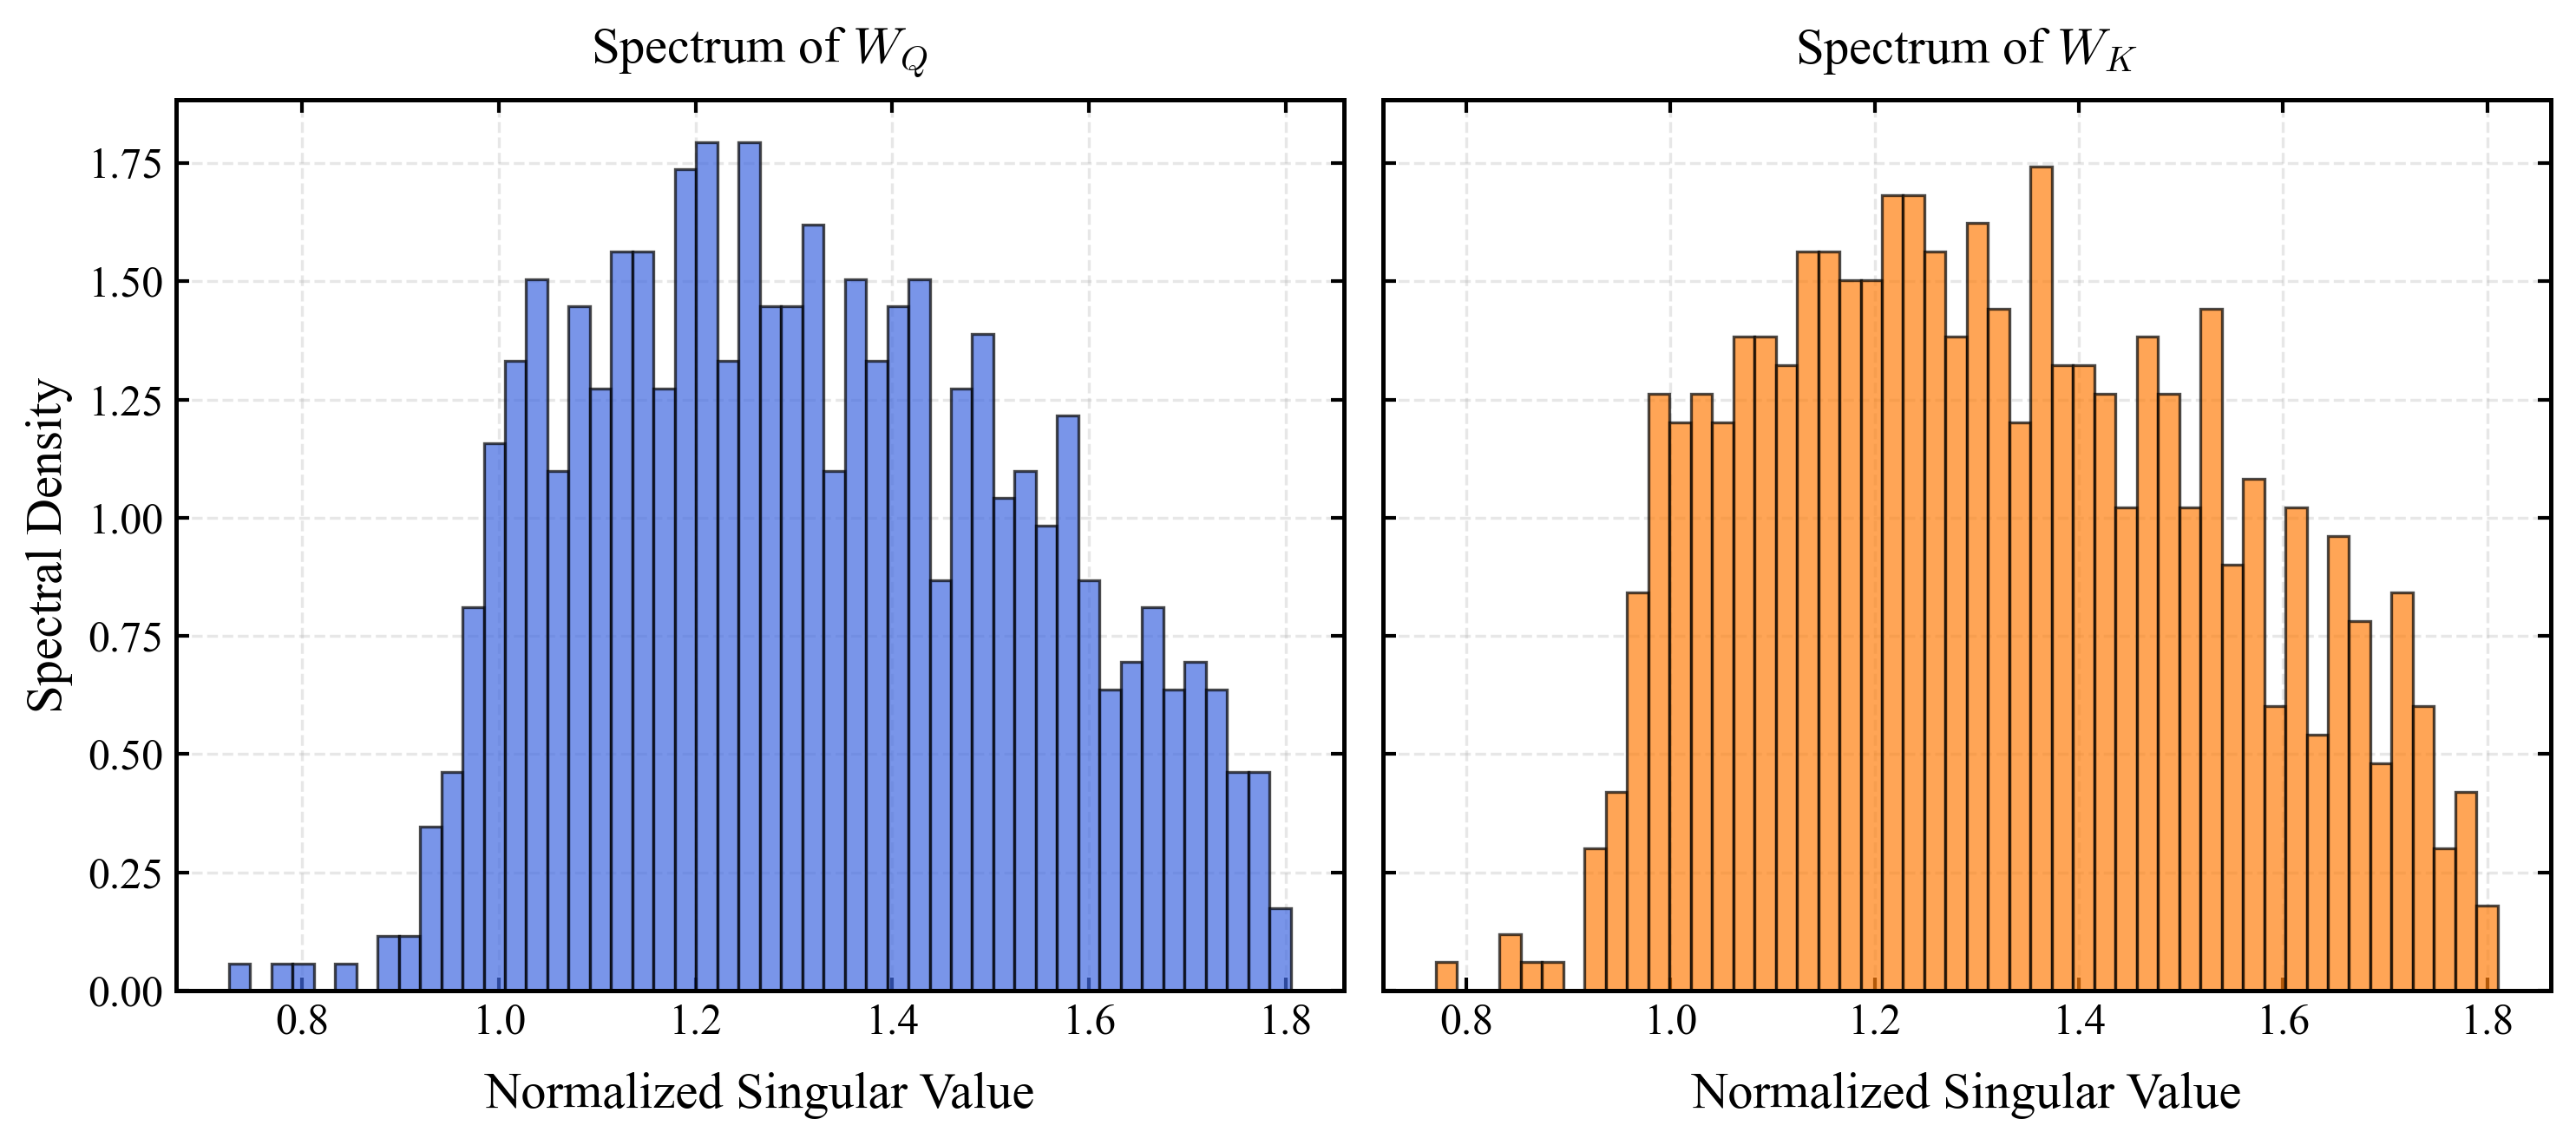


Processing pair: W_Q_runs_11.pkl | W_K_runs_11.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_11.png


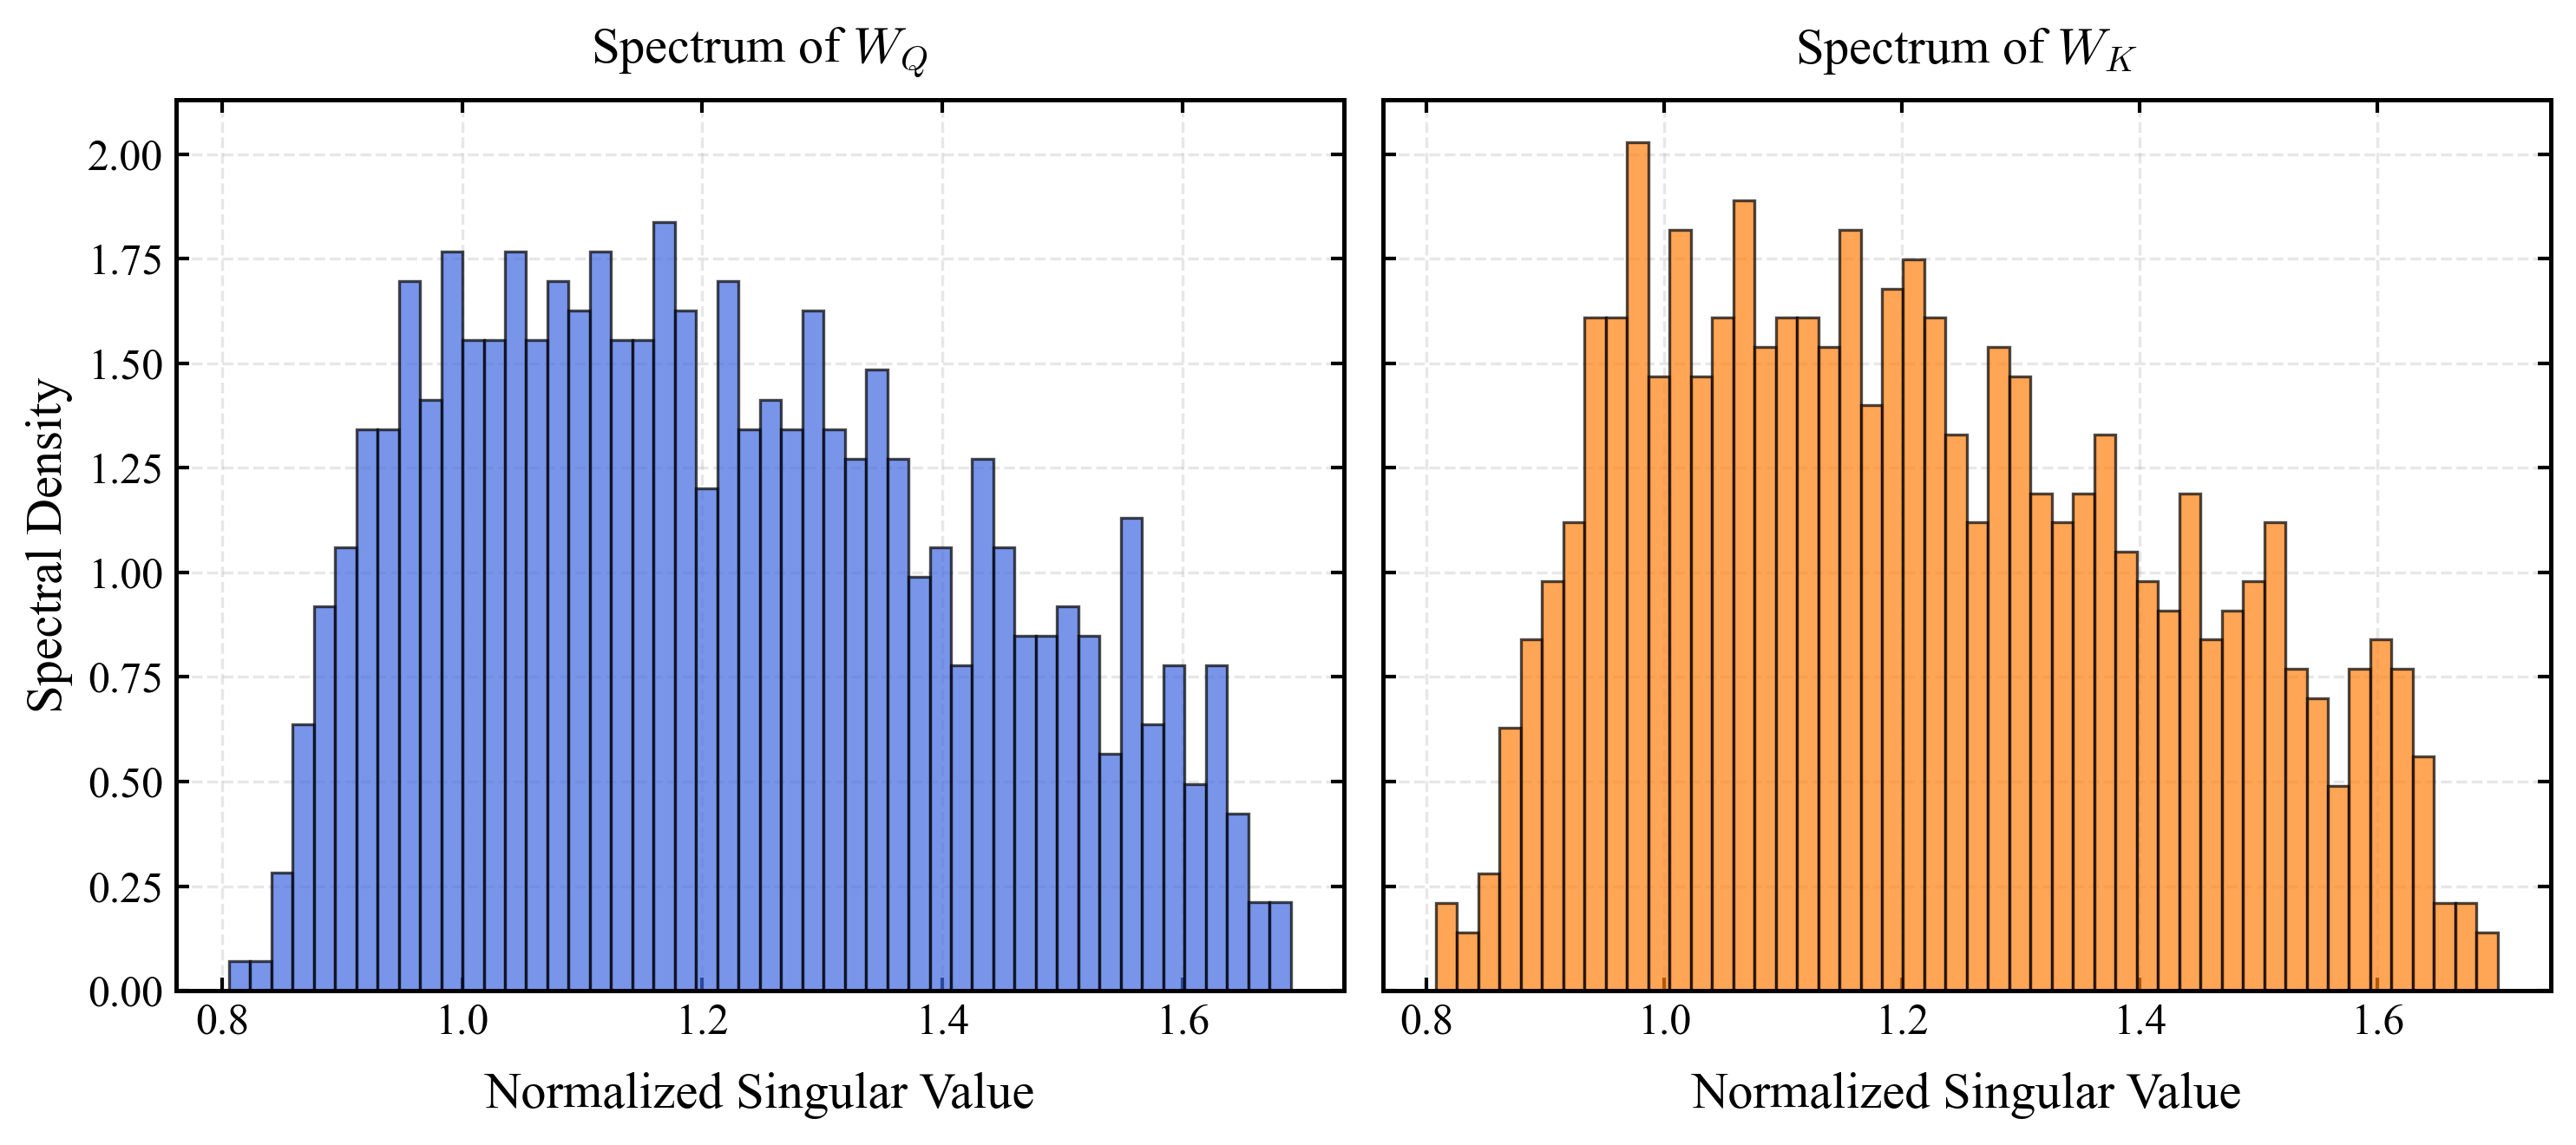


Processing pair: W_Q_runs_12.pkl | W_K_runs_12.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_12.png


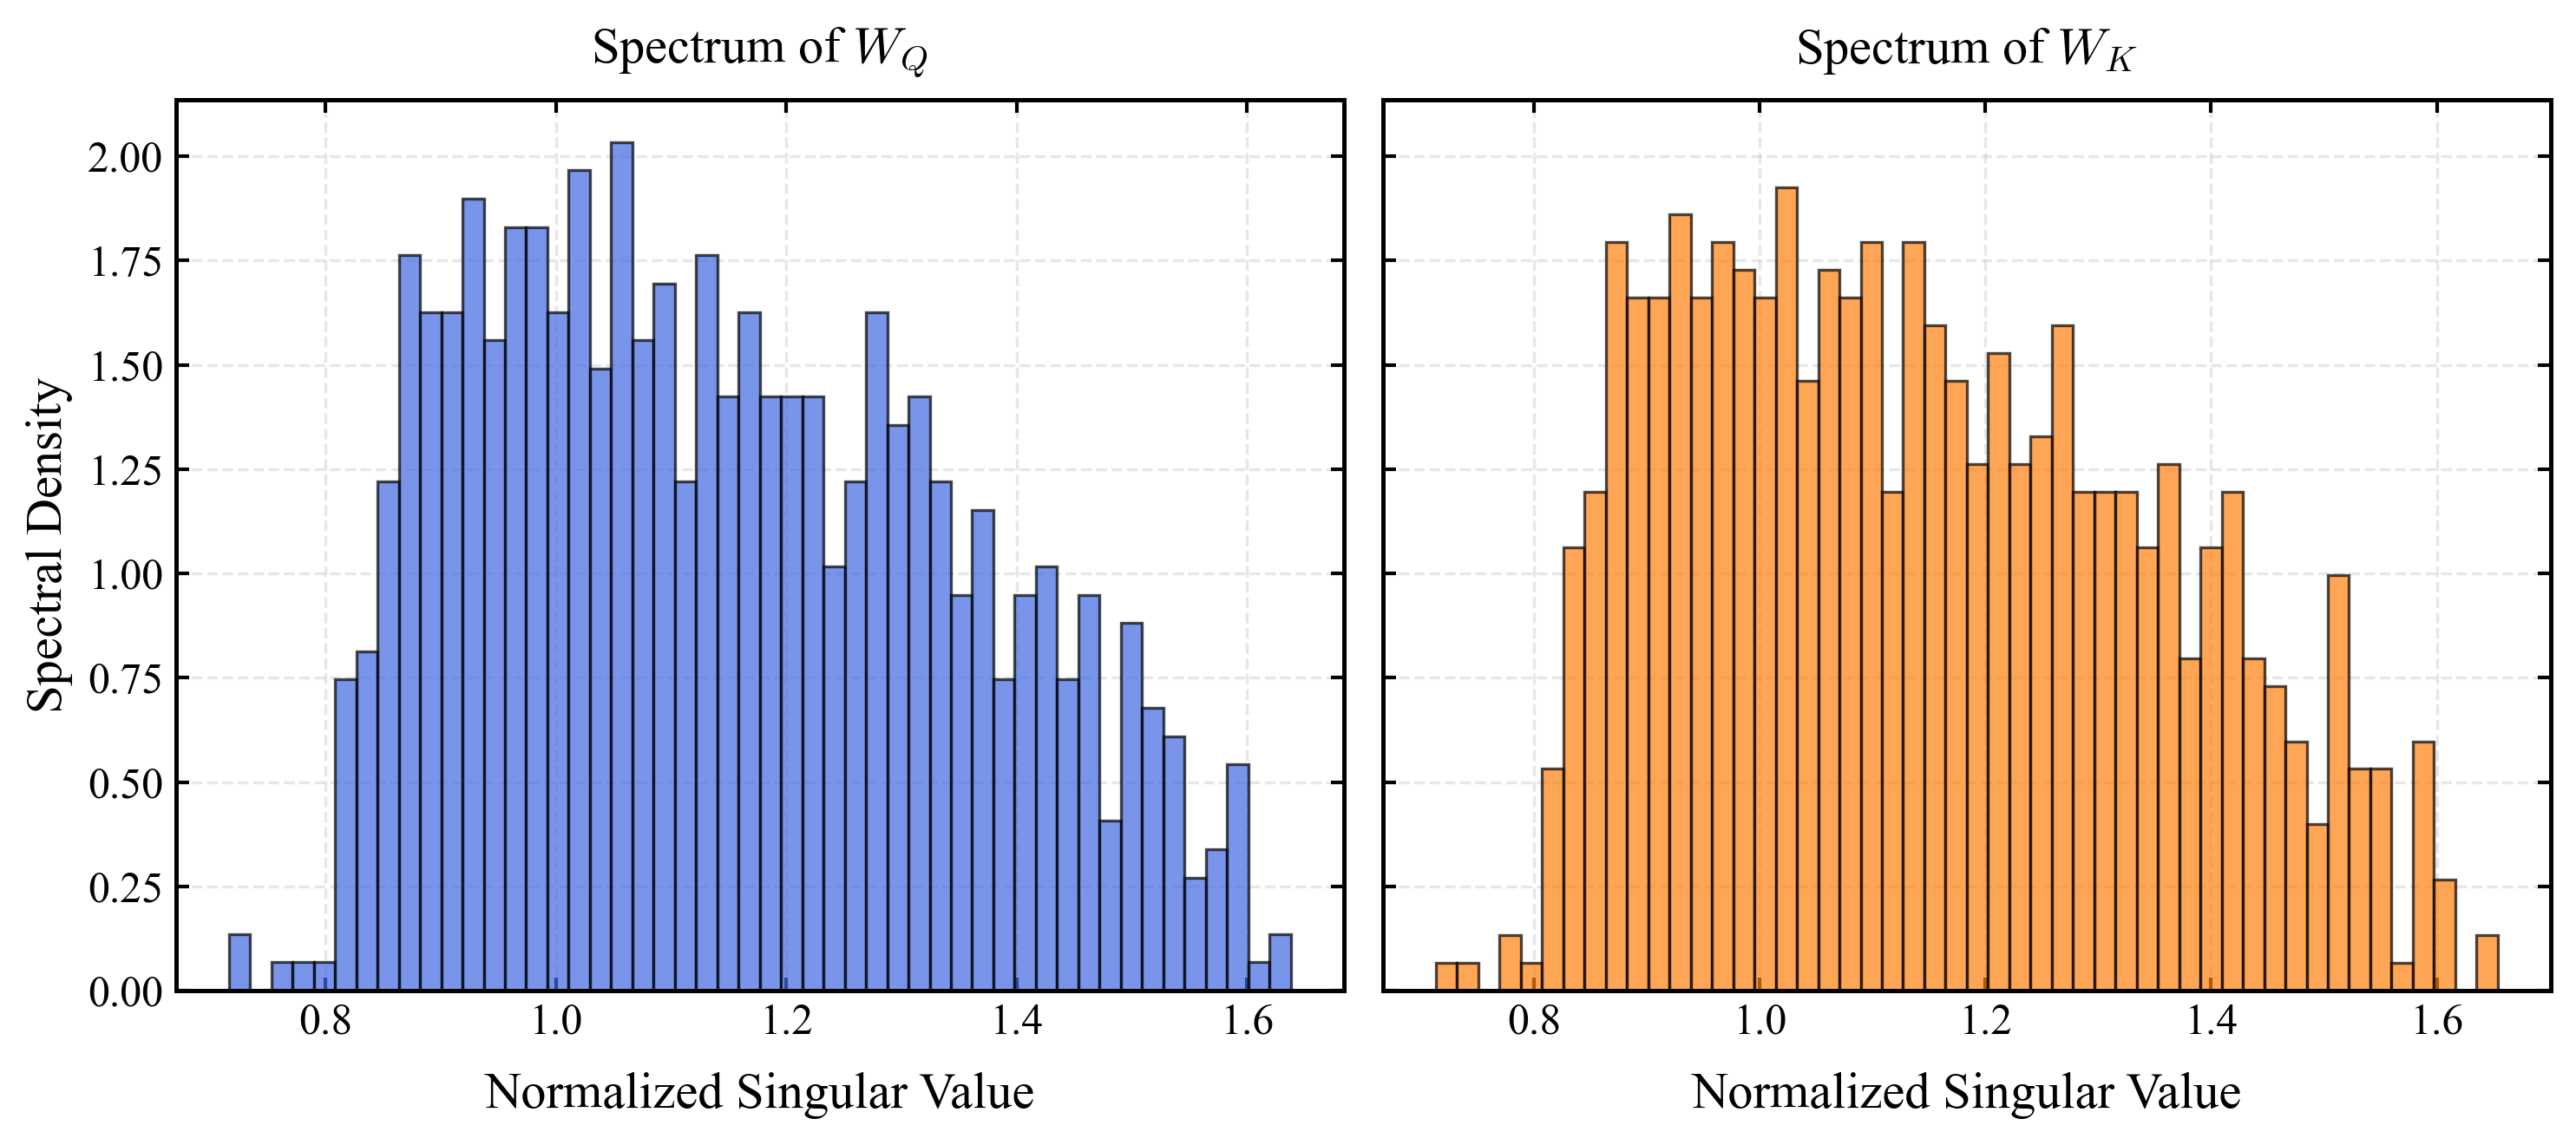


Processing pair: W_Q_runs_13.pkl | W_K_runs_13.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_13.png


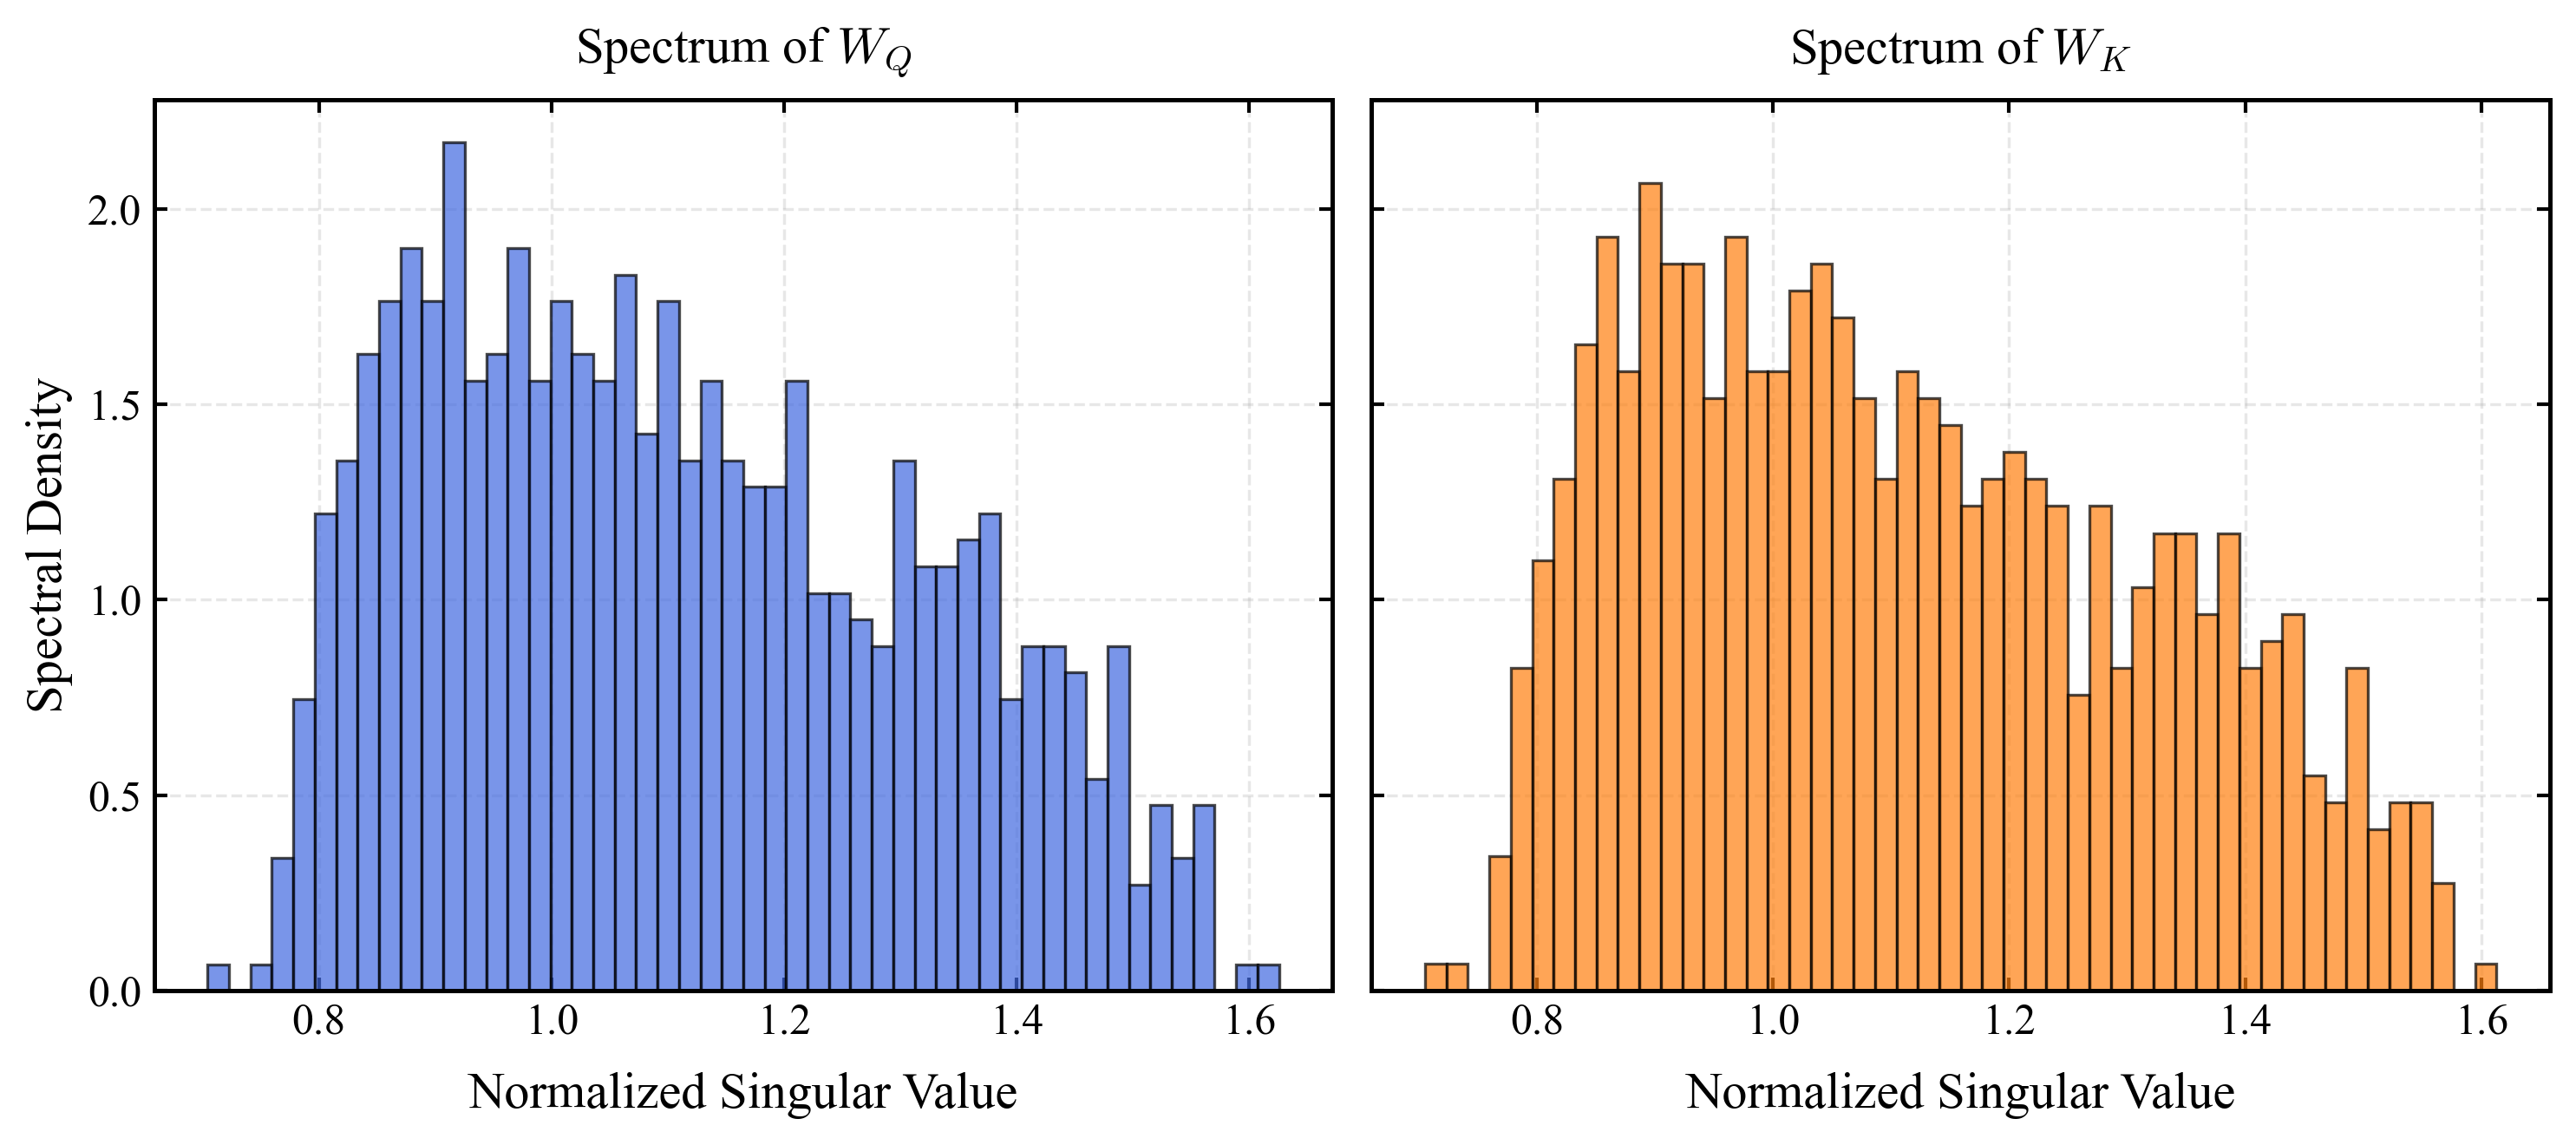


Processing pair: W_Q_runs_14.pkl | W_K_runs_14.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_14.png


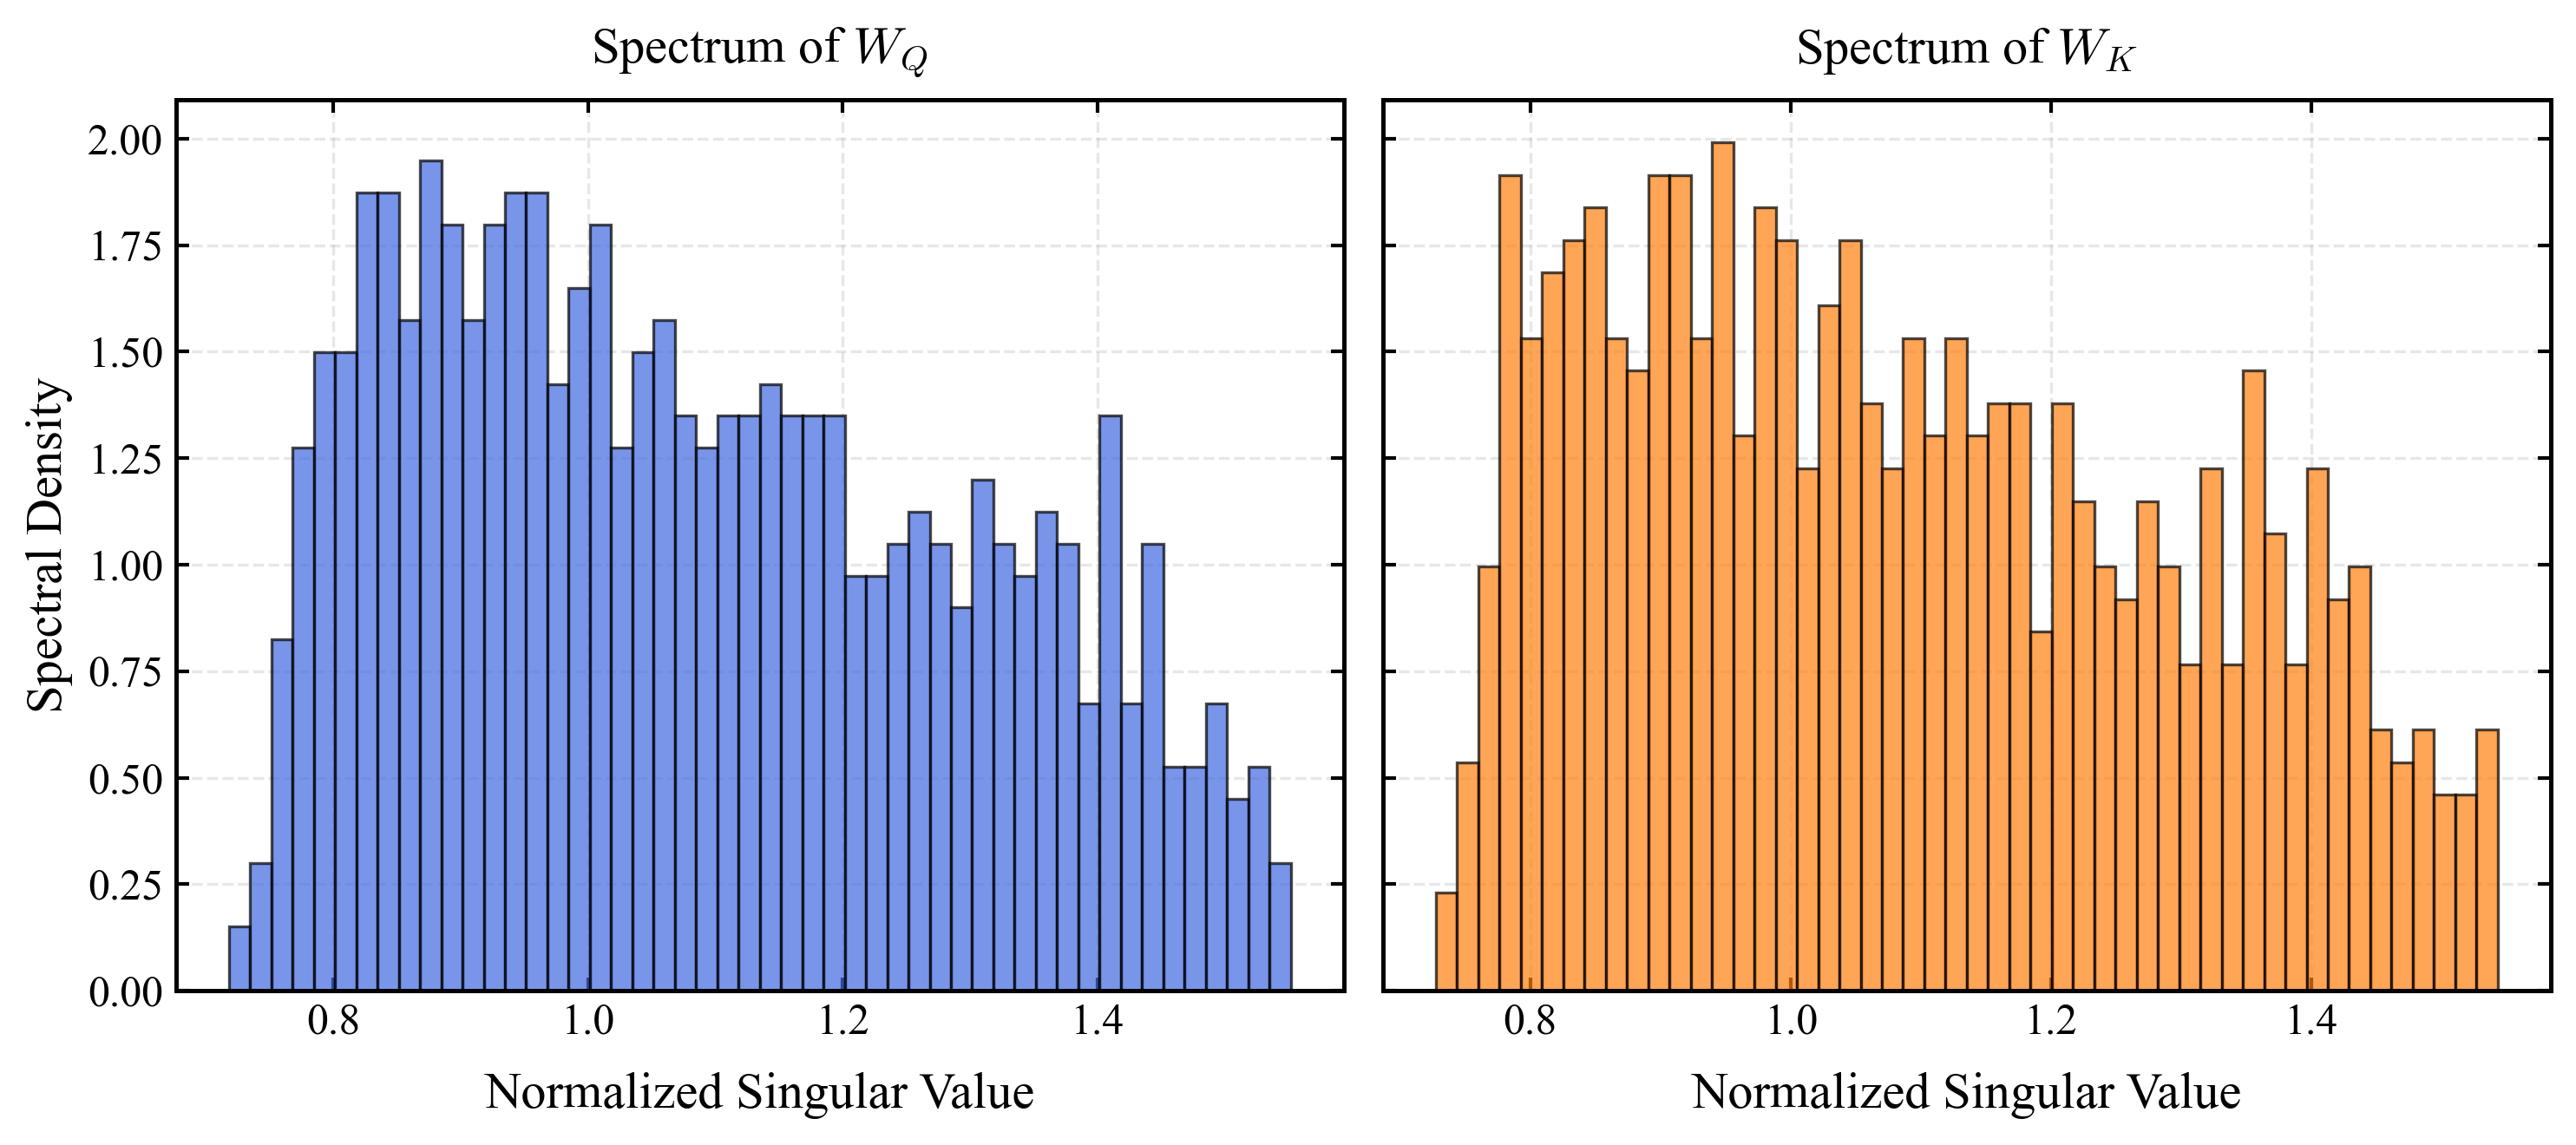


Processing pair: W_Q_runs_2.pkl | W_K_runs_2.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_2.png


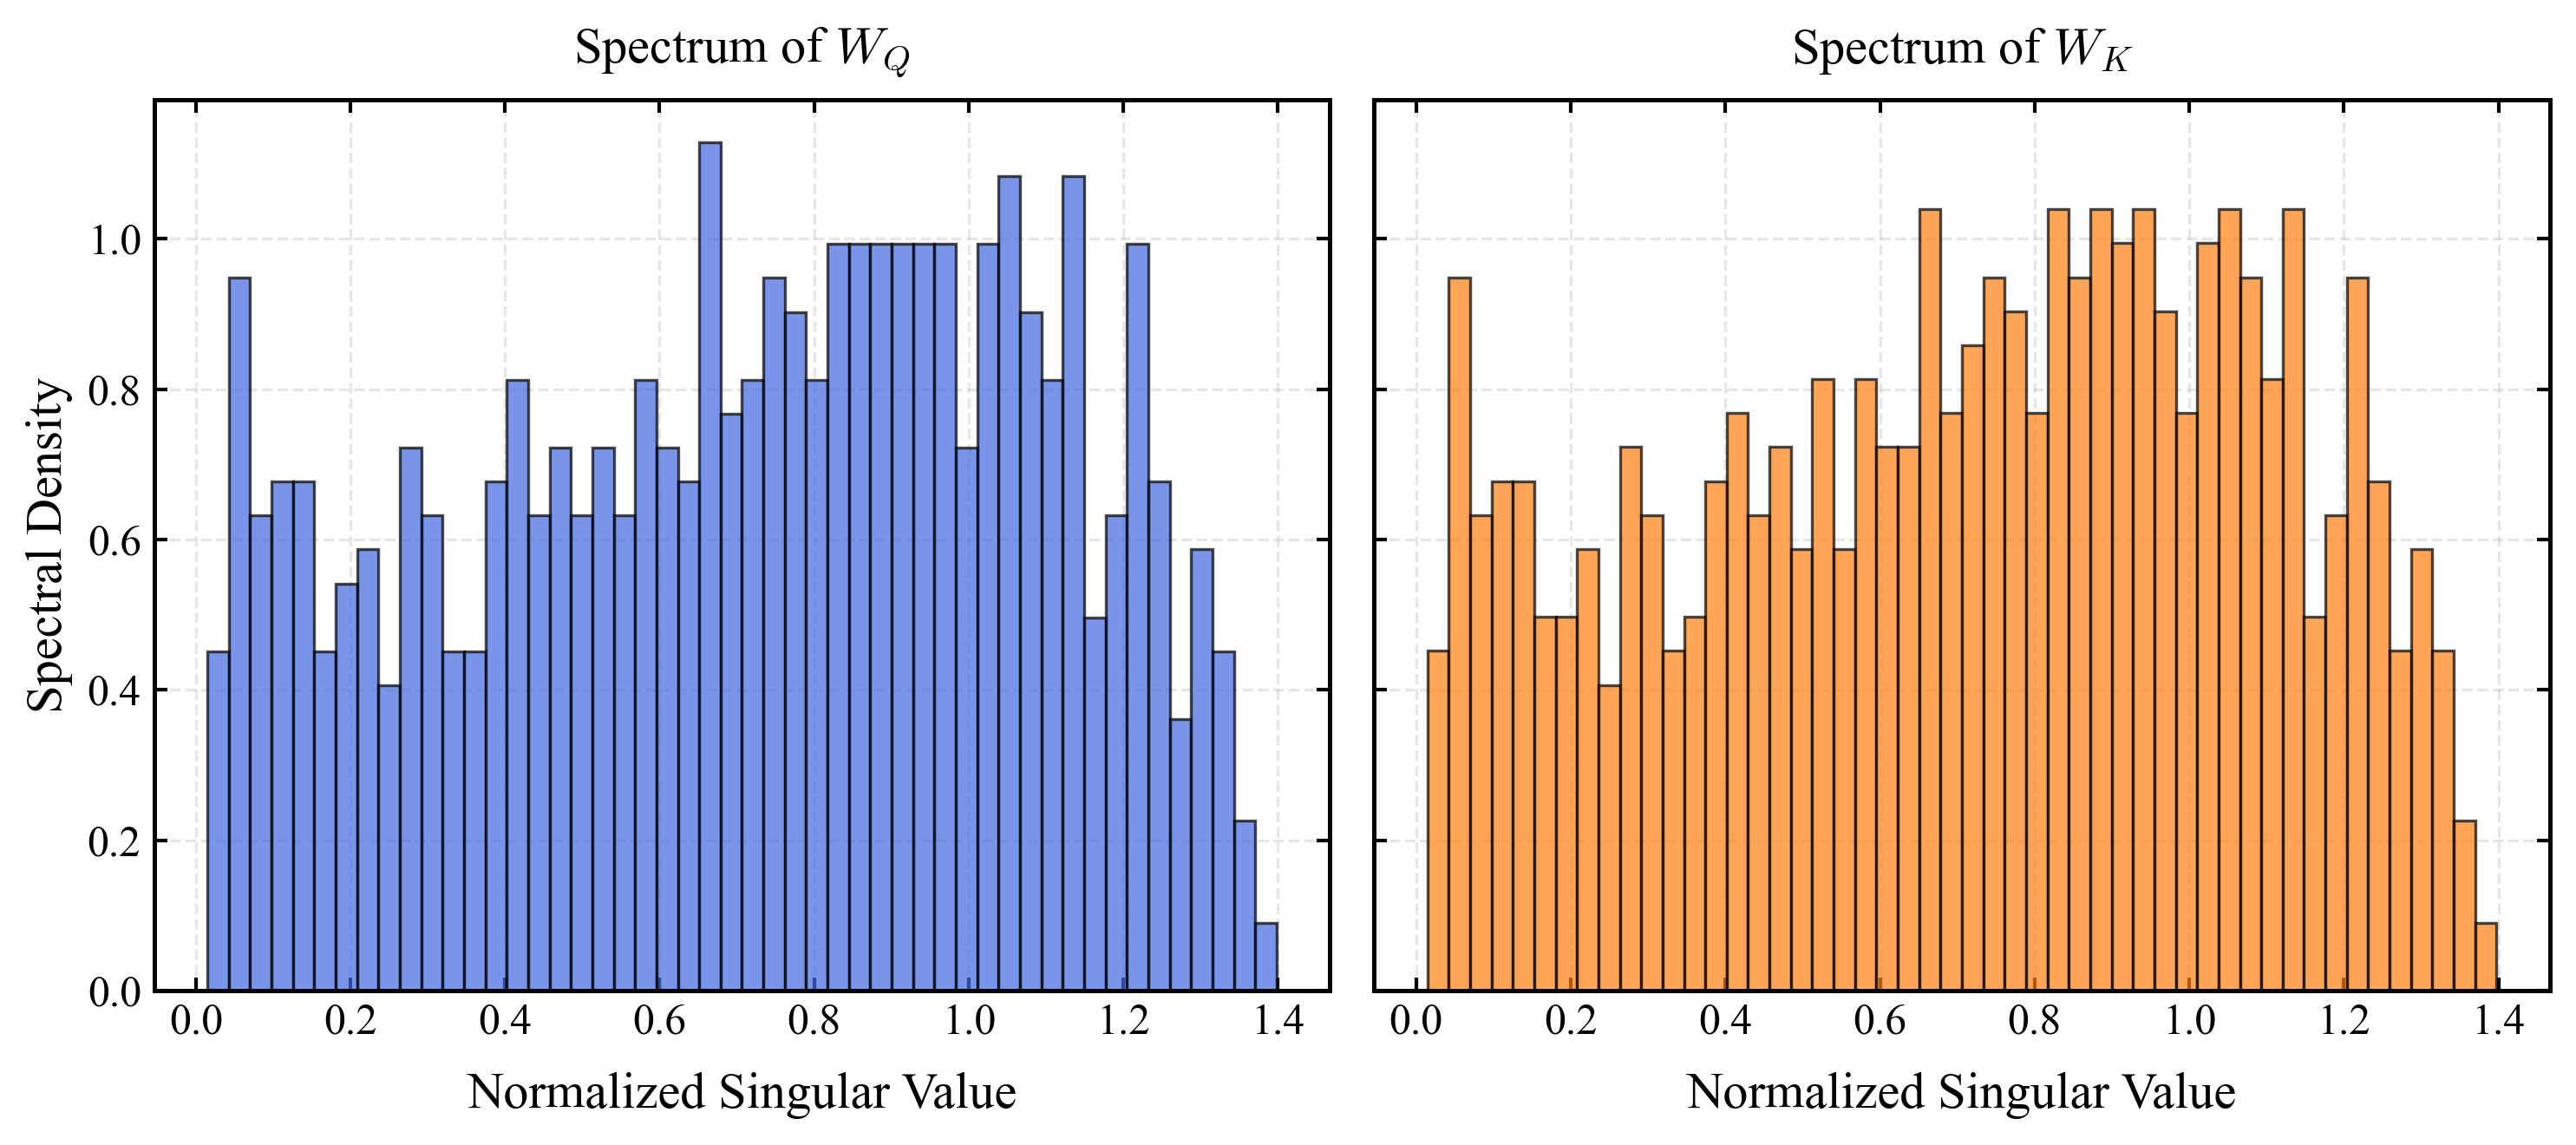


Processing pair: W_Q_runs_3.pkl | W_K_runs_3.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_3.png


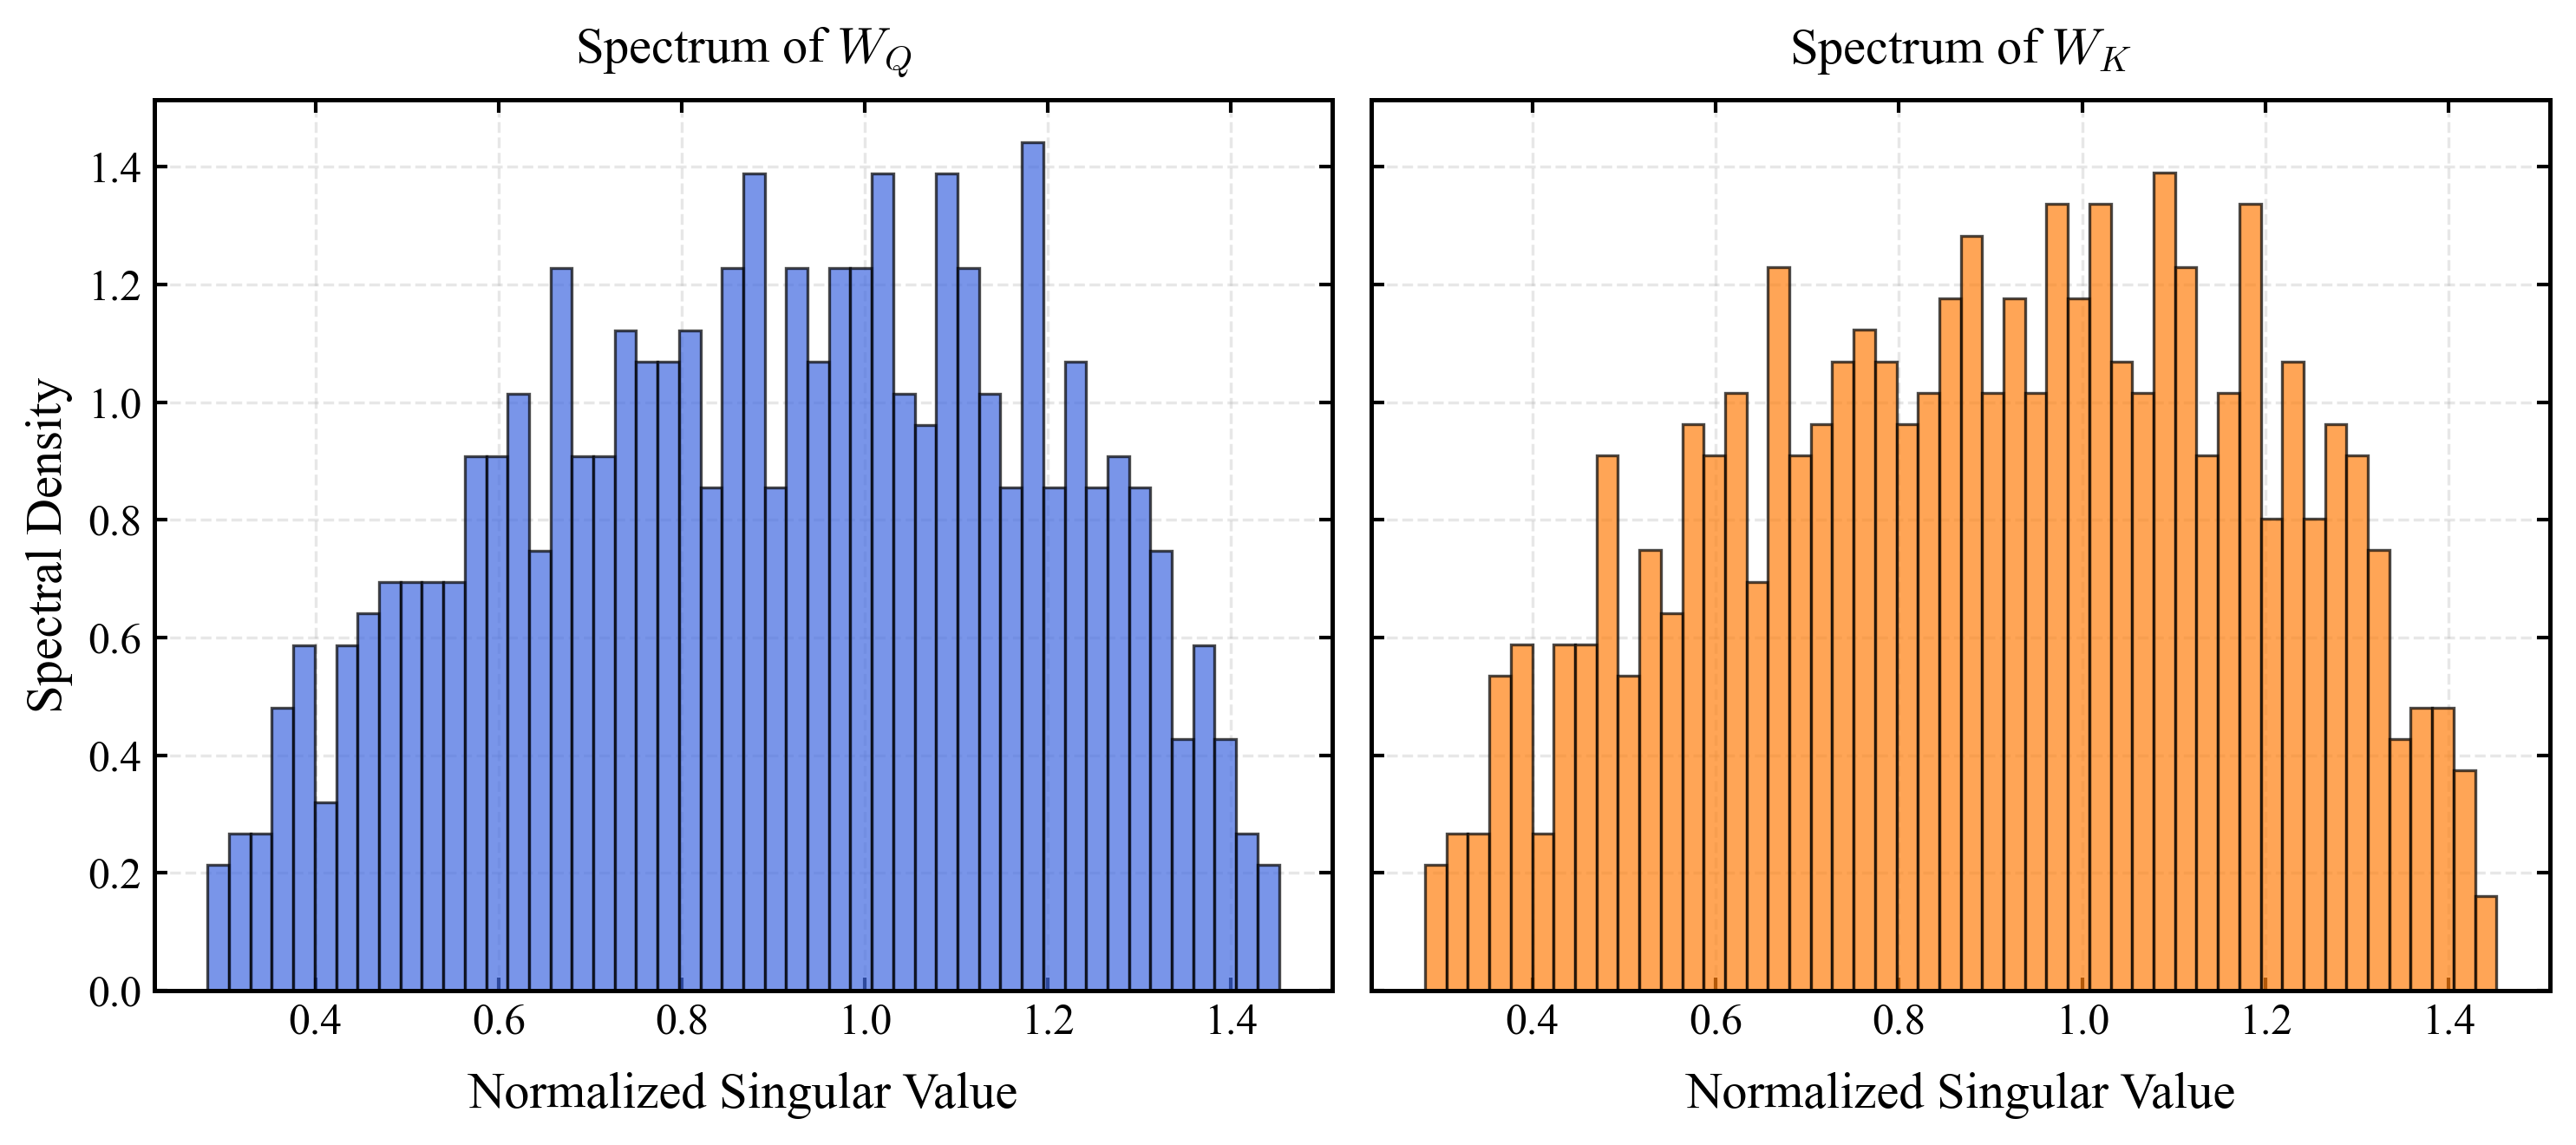


Processing pair: W_Q_runs_4.pkl | W_K_runs_4.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_4.png


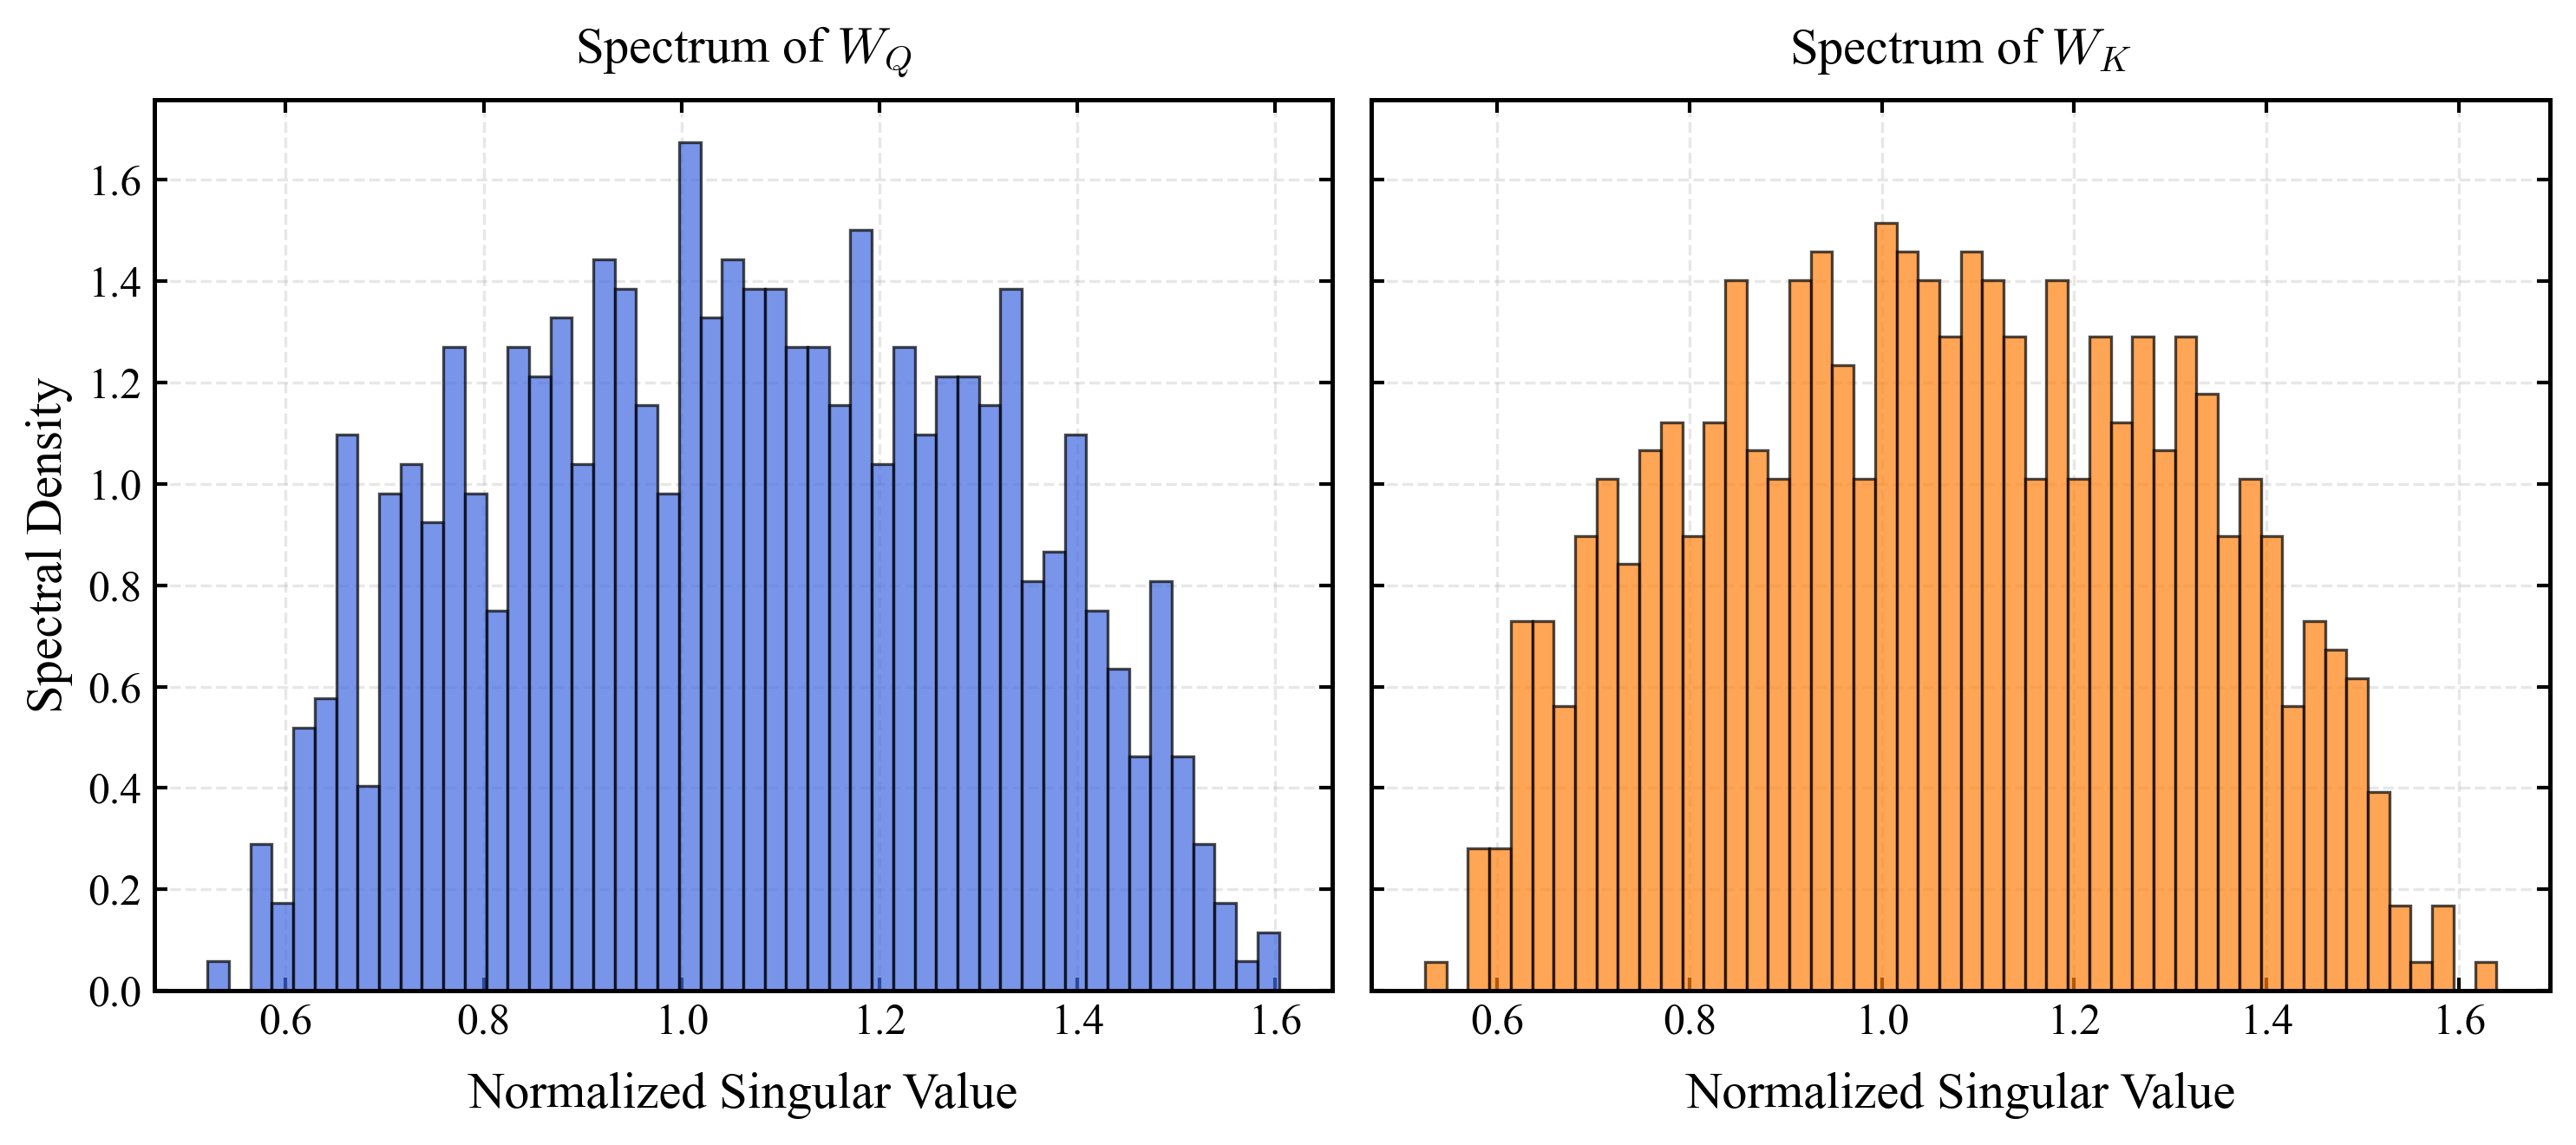


Processing pair: W_Q_runs_5.pkl | W_K_runs_5.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_5.png


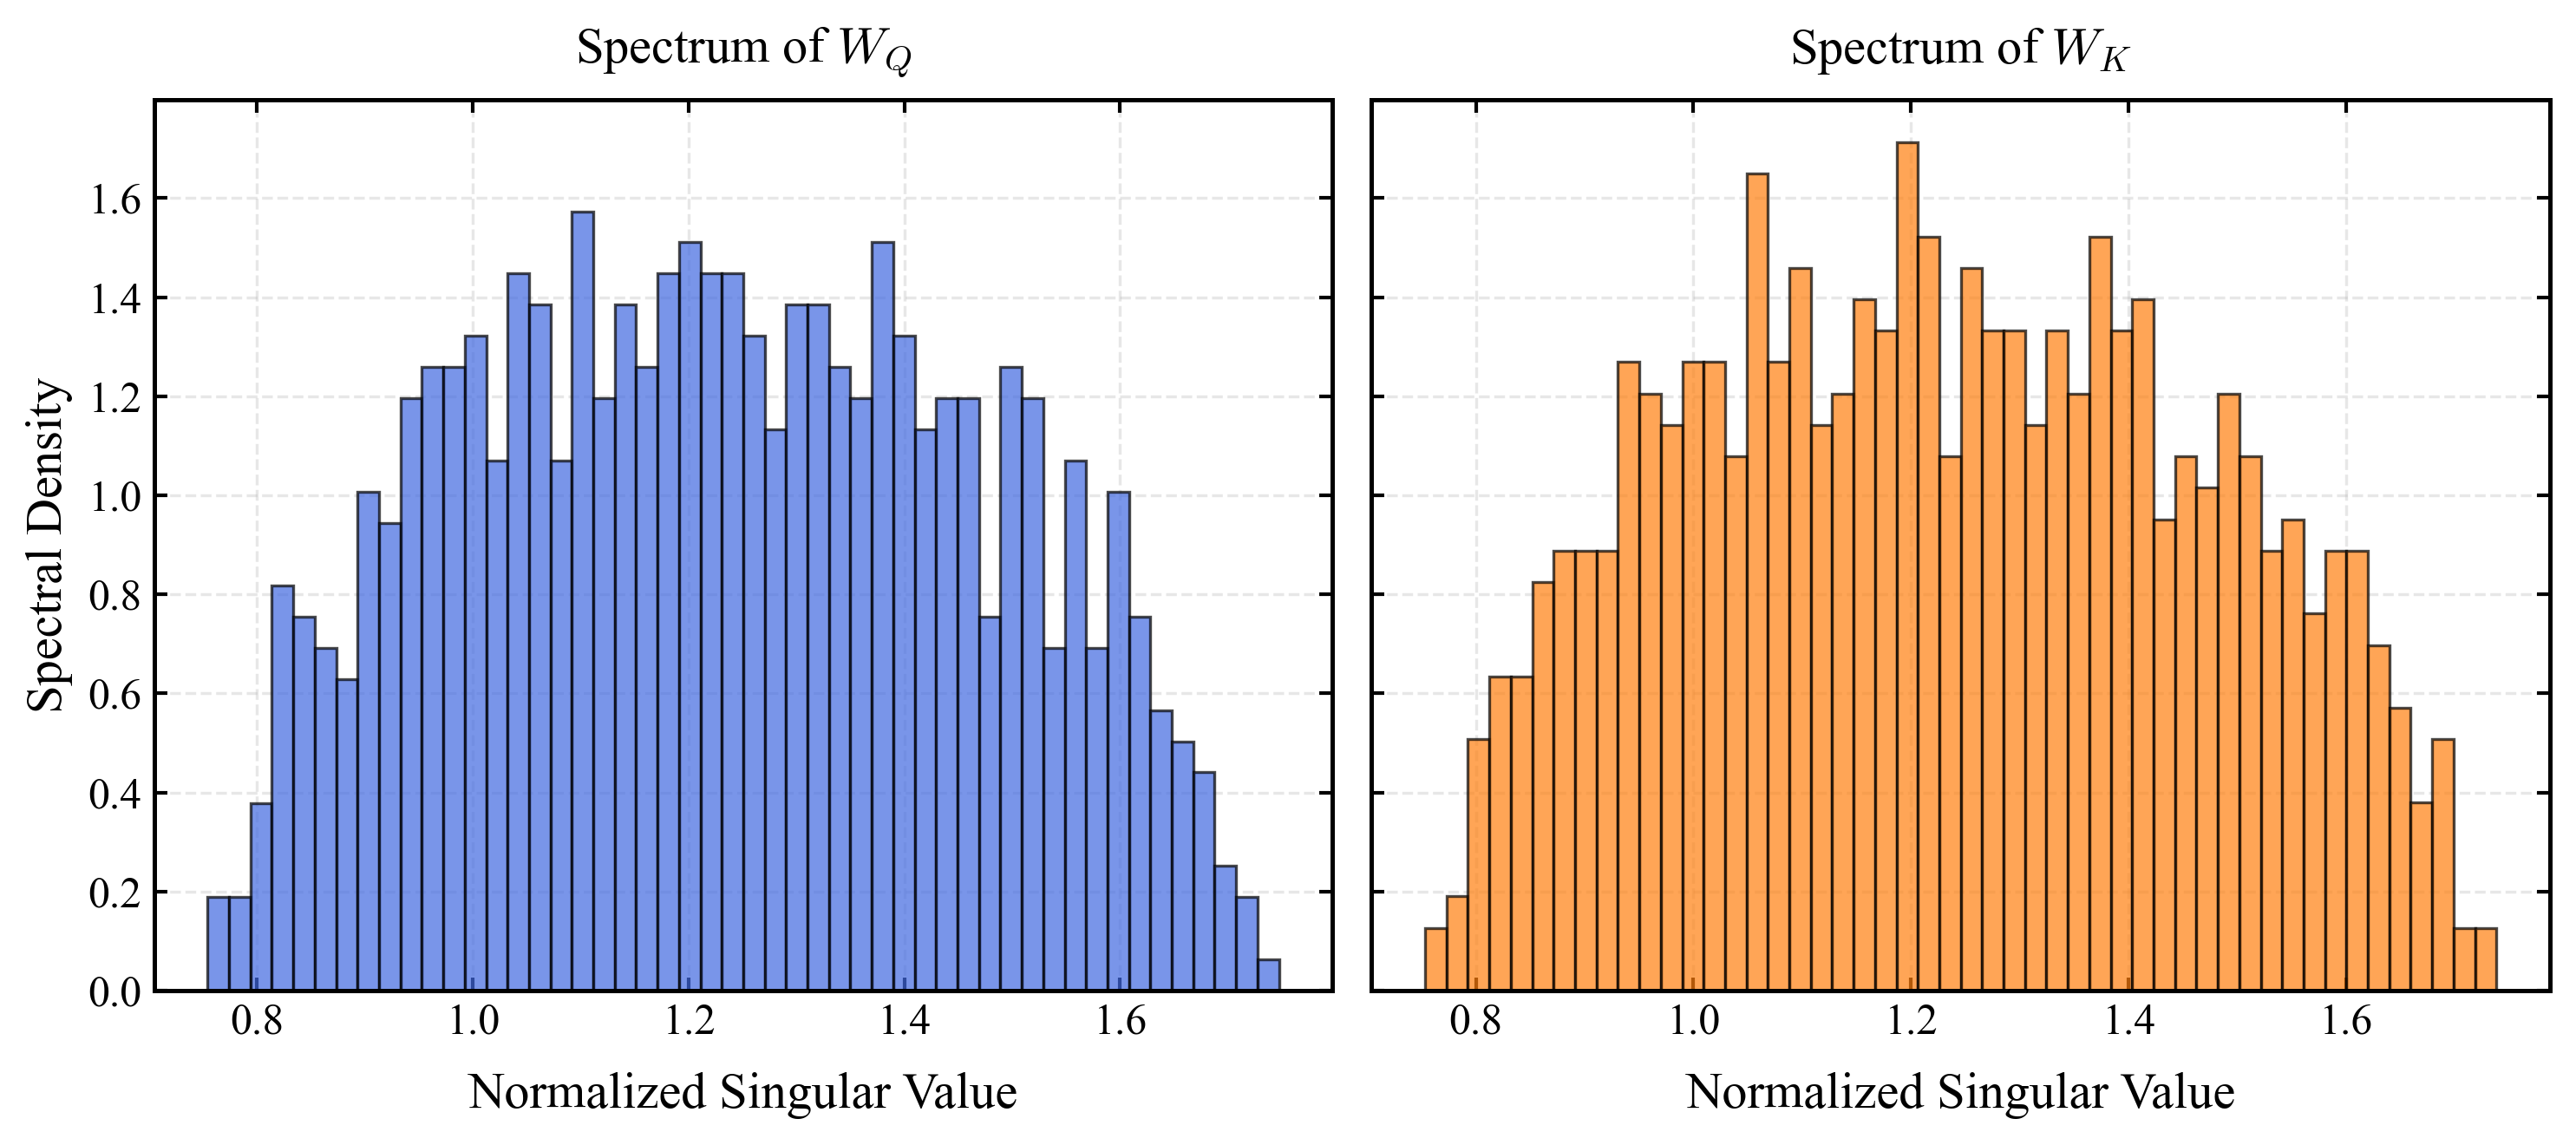


Processing pair: W_Q_runs_6.pkl | W_K_runs_6.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_6.png


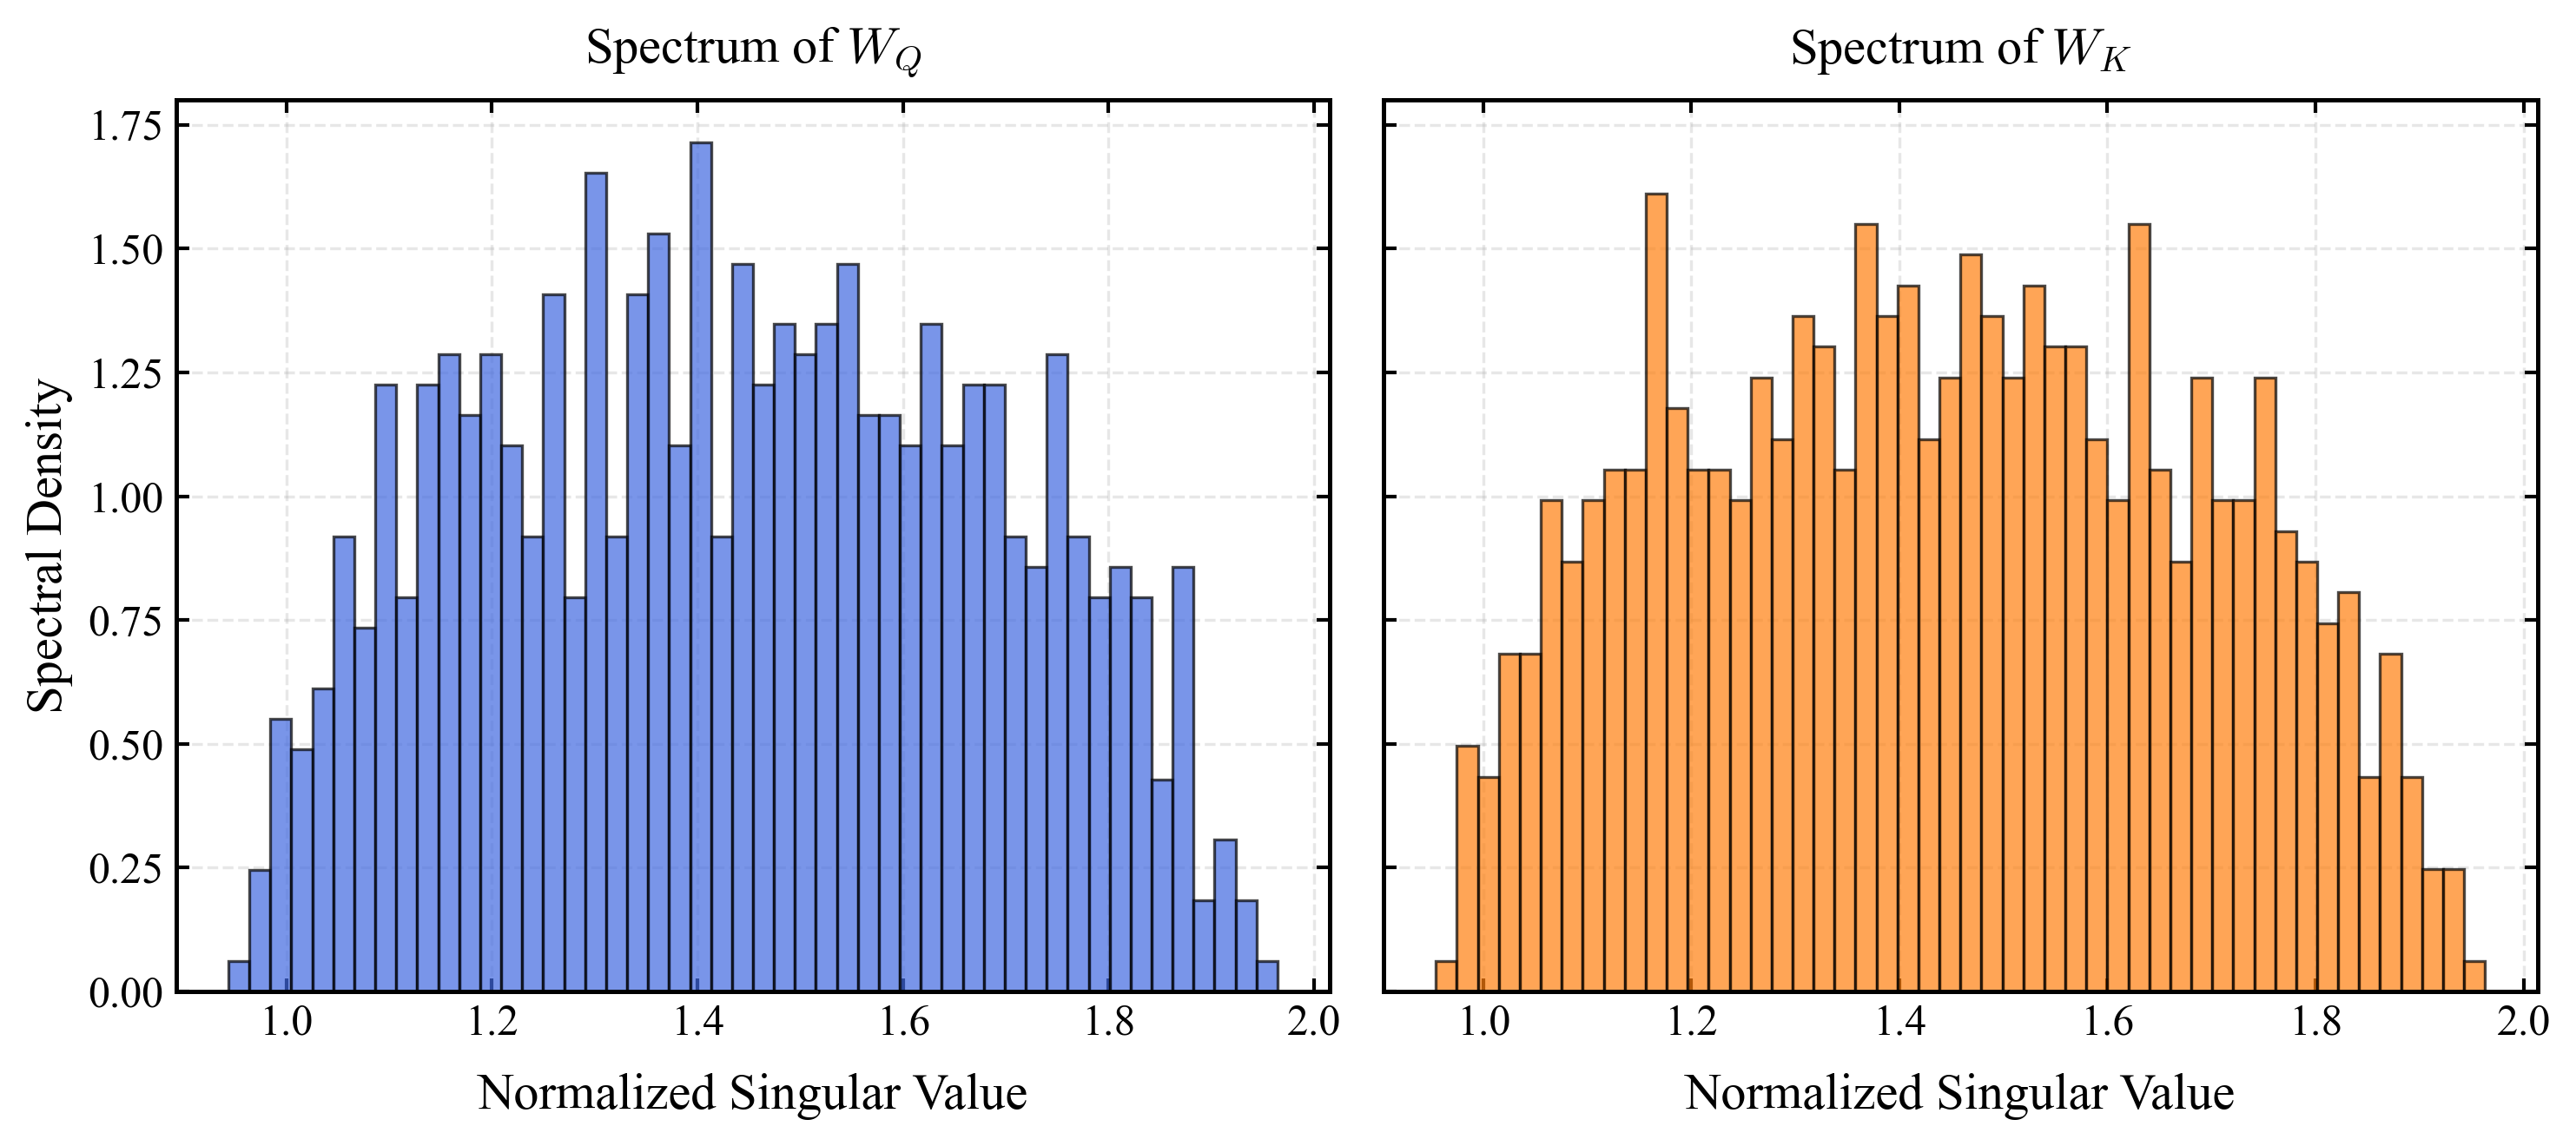


Processing pair: W_Q_runs_7.pkl | W_K_runs_7.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_7.png


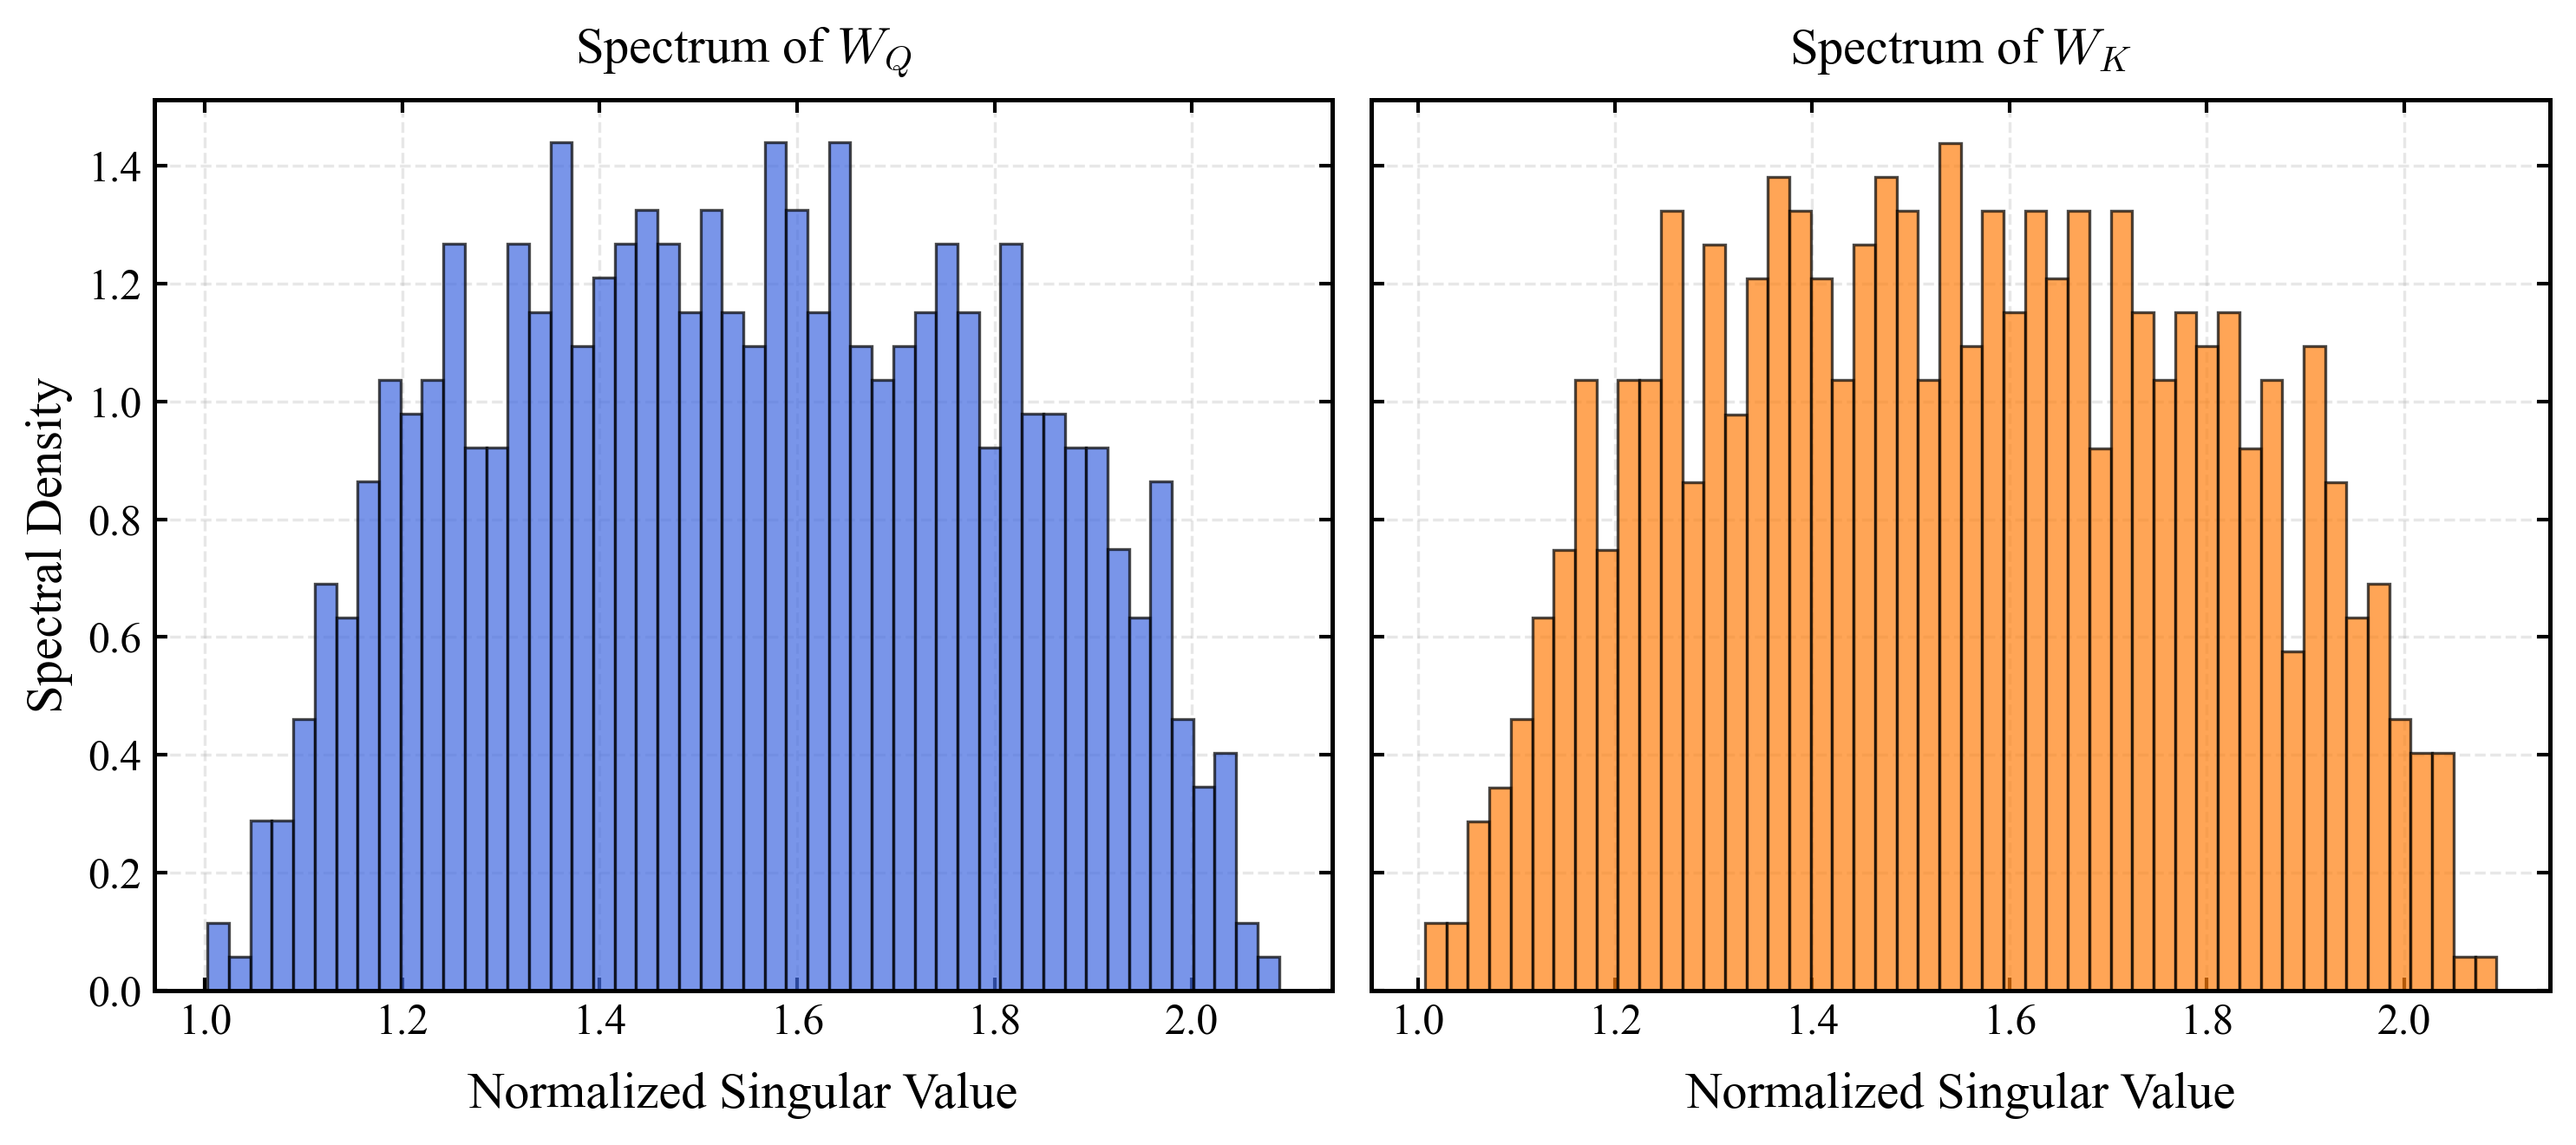


Processing pair: W_Q_runs_8.pkl | W_K_runs_8.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_8.png


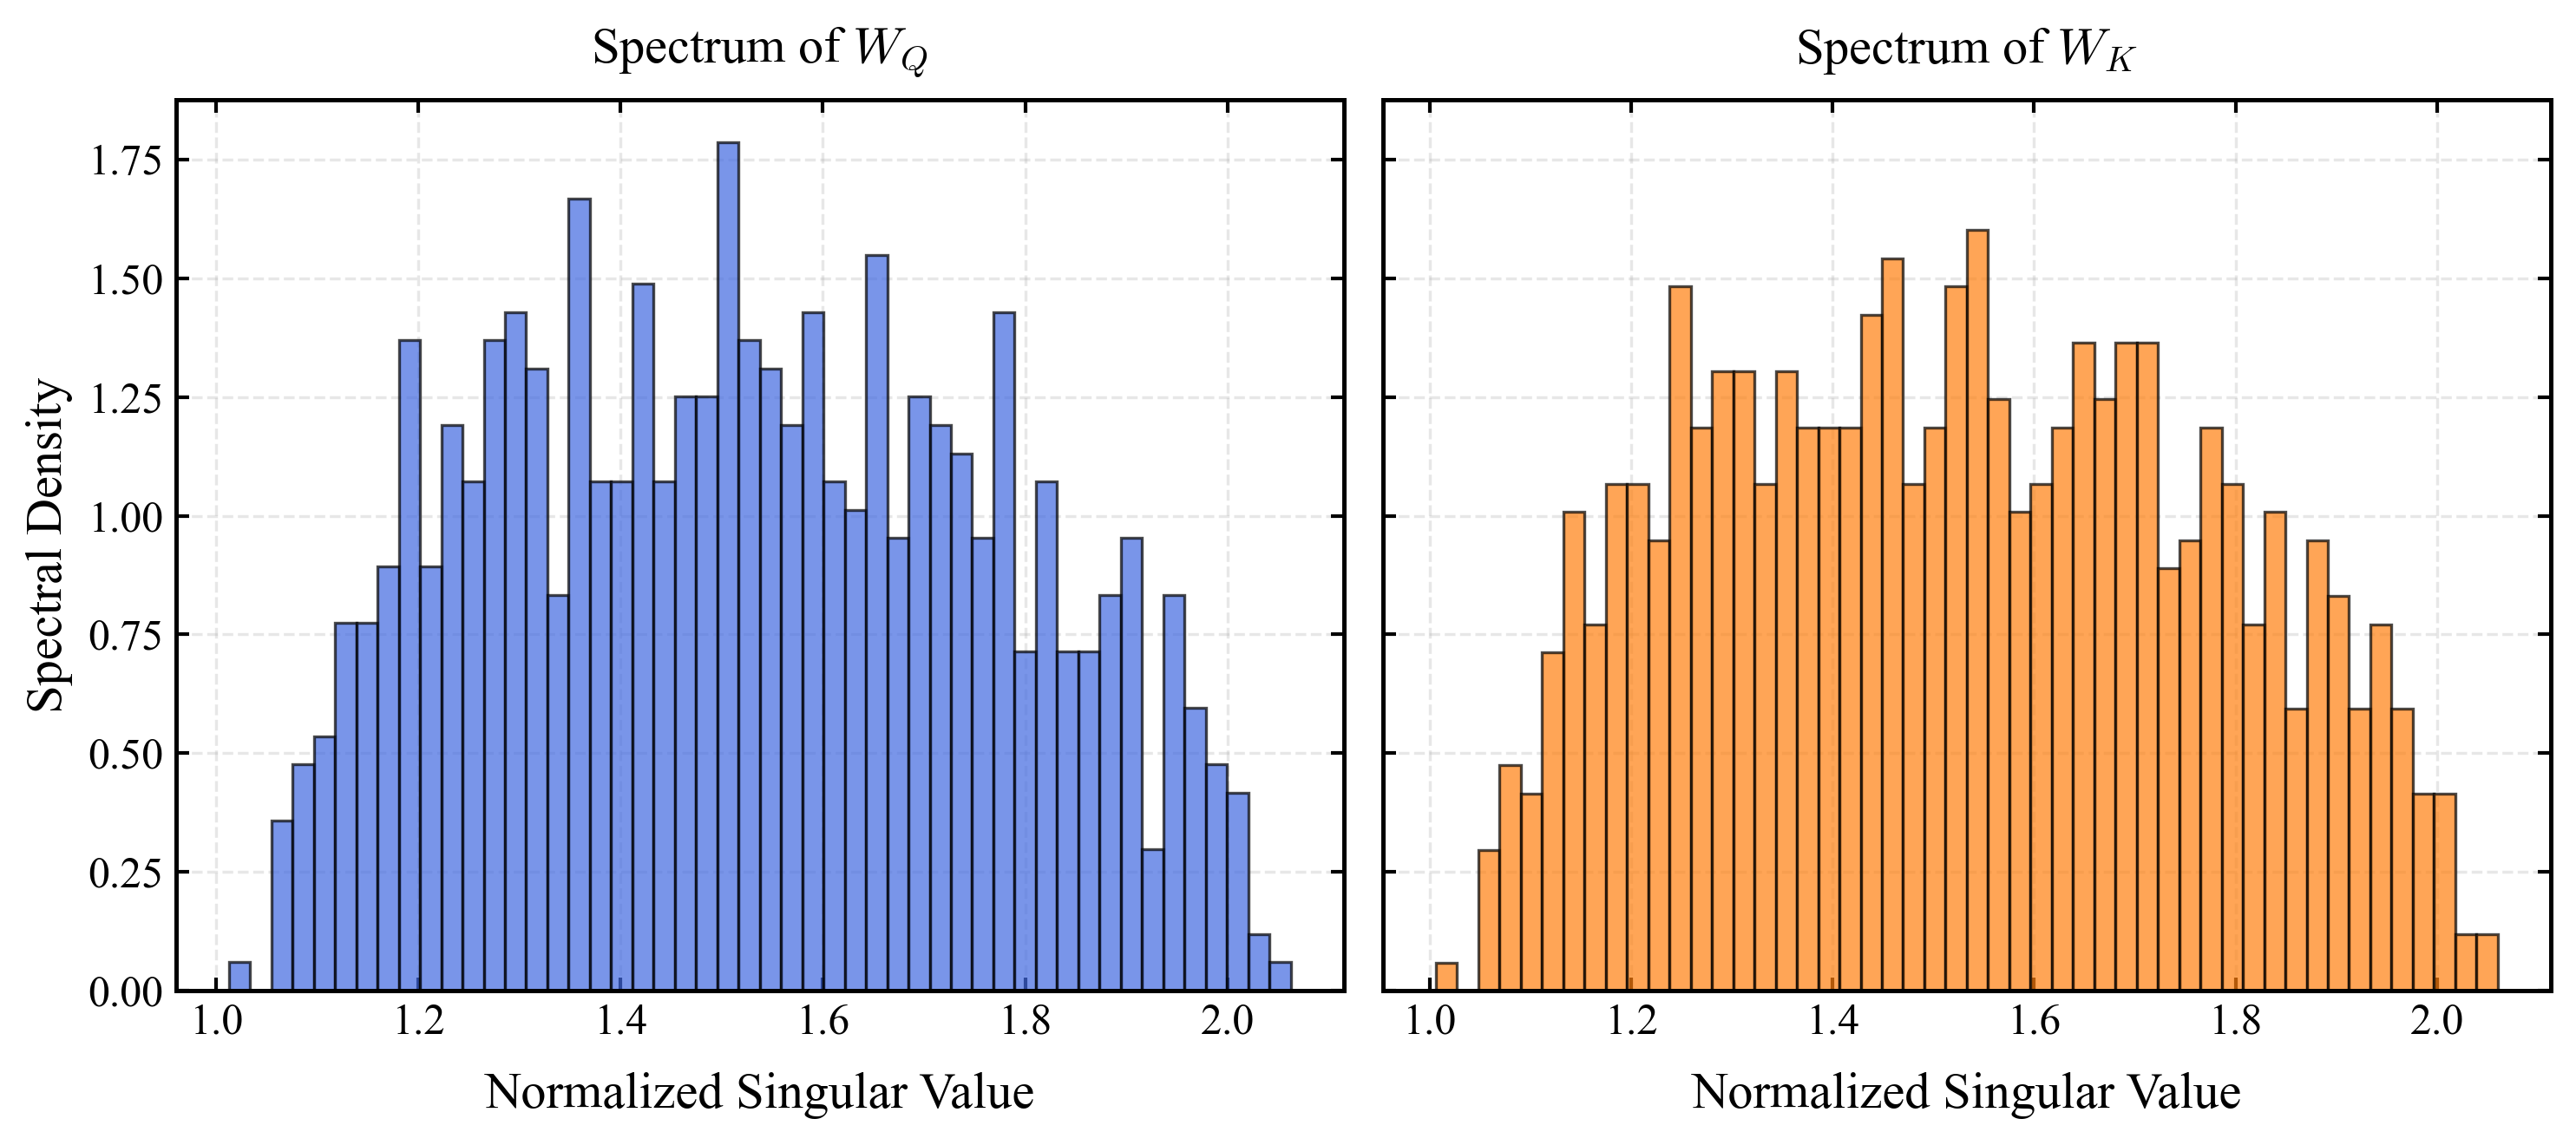


Processing pair: W_Q_runs_9.pkl | W_K_runs_9.pkl
   ✅ Saved plot: ../results/run_20251215_1148/plots/Compare_QK_idx4_W_Q_runs_9.png


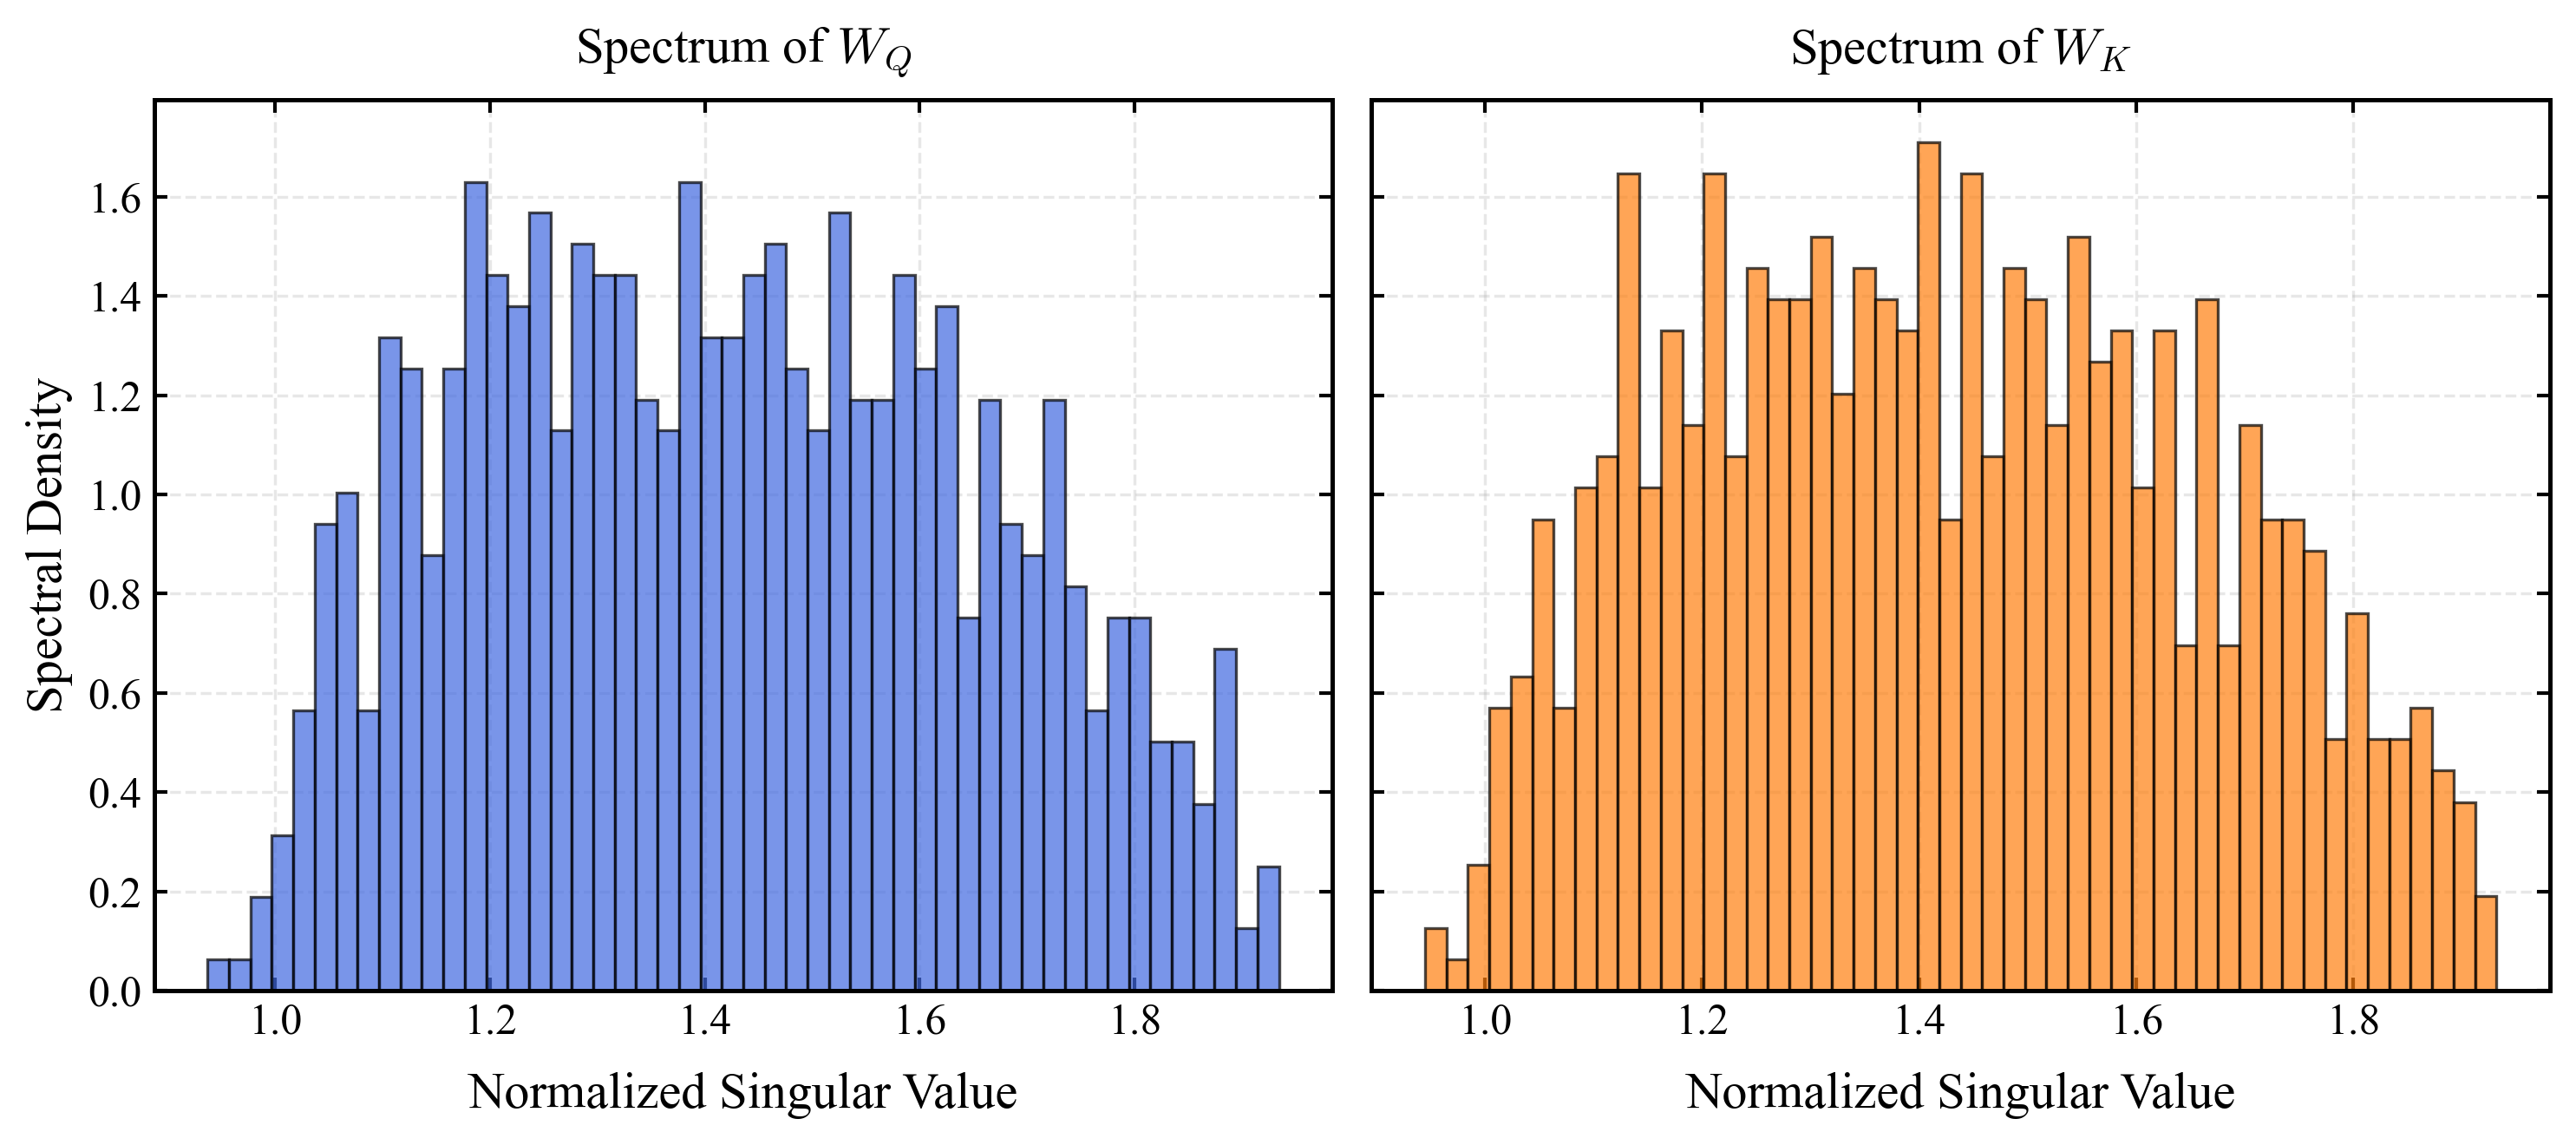

In [6]:
# --- 2. Paramètres ---
lambda_index = 4

# Assurez-vous que 'config' est chargé ou définissez D et R manuellement
# Exemple de fallback si config n'existe pas dans ce contexte
if 'config' in locals():
    D = config["D"].iloc[0]
    R = config["rho"].iloc[0] * D
else:
    D = 100 # Valeur par défaut à adapter
    R = 75  # Valeur par défaut à adapter
    print("⚠️ Warning: 'config' not found. Using default D and R.")

print(f"Normalization constants: D={D}, R={R}")

# --- 3. Helper Function pour le style ---
def plot_hist_on_ax(ax, data, title, color, label_prefix):
    """Trace un histogramme académique sur un ax donné."""
    mu = np.mean(data)
    sigma = np.std(data)
    
    # Histogramme (Density = True est le standard académique)
    ax.hist(
        data, 
        bins=50, 
        density=True, 
        alpha=0.7, 
        color=color, 
        edgecolor="black",
        linewidth=0.8,
        label=fr"{label_prefix}" + "\n" + fr"$\mu={mu:.2f}, \sigma={sigma:.2f}$"
    )
    
    # Labels
    ax.set_title(title, pad=10)
    ax.set_xlabel("Normalized Singular Value", labelpad=8)
    
    # --- BOX STYLE ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
        
    # ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

# --- 4. Main Loop ---
pkl_Q_files = sorted(glob.glob(os.path.join(run_dir, "W_Q_runs_*.pkl")))
pkl_K_files = sorted(glob.glob(os.path.join(run_dir, "W_K_runs_*.pkl")))

print(f"Found {len(pkl_Q_files)} W_Q files and {len(pkl_K_files)} W_K files.")

for q_file, k_file in zip(pkl_Q_files, pkl_K_files):
    print(f"\nProcessing pair: {os.path.basename(q_file)} | {os.path.basename(k_file)}")

    try:
        with open(q_file, "rb") as fq, open(k_file, "rb") as fk:
            Q_runs_all = pickle.load(fq)
            K_runs_all = pickle.load(fk)

        num_lambda = min(len(Q_runs_all), len(K_runs_all))
        if lambda_index >= num_lambda:
            print(f"   ⚠️ [SKIP] λ-index {lambda_index} out of range (max {num_lambda-1})")
            continue

        # --- Extraction & Normalisation ---
        # Note: On suppose ici que ce sont des listes de matrices
        # On normalise par sqrt(D*R) comme dans votre snippet
        norm_factor = np.sqrt(D)
        
        # Q
        Q_list = Q_runs_all[lambda_index]
        sv_Q = np.concatenate([np.linalg.svd(W, compute_uv=False) for W in Q_list])
        sv_Q = sv_Q / norm_factor # Filtre et Normalise
        
        # K
        K_list = K_runs_all[lambda_index]
        sv_K = np.concatenate([np.linalg.svd(W, compute_uv=False) for W in K_list])
        sv_K = sv_K/ norm_factor # Filtre et Normalise

        # --- Plotting Side-by-Side ---
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True) # sharey pour comparer les hauteurs
        
        # LEFT: Q (Bleu)
        plot_hist_on_ax(
            axes[0], 
            sv_Q, 
            title=r"Spectrum of $W_Q$", 
            color='royalblue', 
            label_prefix="Empirical Q"
        )
        axes[0].set_ylabel("Spectral Density") # Seulement à gauche

        # RIGHT: K (Orange ou autre couleur distinctive)
        plot_hist_on_ax(
            axes[1], 
            sv_K, 
            title=r"Spectrum of $W_K$", 
            color='#ff7f0e', # Orange
            label_prefix="Empirical K"
        )
        
        # Layout adjustment
        plt.tight_layout()
        
        # Save
        filename = f"Compare_QK_idx{lambda_index}_{os.path.basename(q_file).replace('.pkl', '.png')}"
        save_path = os.path.join(plot_path, filename)
        plt.savefig(save_path)
        print(f"   ✅ Saved plot: {save_path}")
        plt.show()
        
    except Exception as e:
        print(f"   ❌ Error processing files: {e}")